In [76]:
import numpy as np
import pandas as pd
import pystan
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genextreme


# 0. Definición de funciones

In [77]:
def plot_station_timeseries(data, figsize=(20, 20)):
    """
    Crea scatter plots de las series temporales de precipitación máxima por estación.
    """
    # Número de estaciones
    n_stations = len(data.columns)
    
    # Calcular layout óptimo para los subplots
    n_rows = int(np.ceil(n_stations/2))  # 2 columnas
    
    # Crear figura
    fig, axs = plt.subplots(n_rows, 2, figsize=figsize)
    if n_rows == 1:
        axs = axs.reshape(1, -1)
    
    # Convertir índice a años numéricos para los cálculos
    years = pd.to_datetime(data.index).year
    
    # Plotear cada estación
    for idx, station in enumerate(data.columns):
        row = idx // 2
        col = idx % 2
        
        ax = axs[row, col]
        
        # Obtener datos no faltantes y sus años correspondientes
        station_data = data[station].dropna()
        valid_mask = ~data[station].isna()
        valid_years = years[valid_mask]
        
        # Scatter plot de los datos
        ax.scatter(valid_years, station_data, 
                  color='blue', 
                  alpha=0.6,
                  label='Observaciones')
        
        if len(station_data) > 1:  # Si hay al menos 2 puntos para la tendencia
            # Línea de tendencia usando años numéricos
            z = np.polyfit(valid_years, station_data, 1)
            p = np.poly1d(z)
            
            # Crear años continuos para la línea de tendencia
            trend_years = np.linspace(valid_years.min(), valid_years.max(), 100)
            ax.plot(trend_years, p(trend_years), "r--", 
                   alpha=0.8, label=f'Tendencia ({z[0]:.2f} mm/año)')
        
        # Estadísticas básicas
        mean_val = station_data.mean()
        std_val = station_data.std()
        
        # Líneas de media y ±2std
        ax.axhline(y=mean_val, color='g', linestyle='--', alpha=0.5, label='Media')
        ax.axhline(y=mean_val + 2*std_val, color='g', linestyle=':', alpha=0.3)
        ax.axhline(y=mean_val - 2*std_val, color='g', linestyle=':', alpha=0.3)
        
        # Personalizar plot
        ax.set_title(f'Estación {station}')
        ax.set_xlabel('Años')
        ax.set_ylabel('Pmax (mm)')
        
        # Ajustar eje x específico para esta estación
        ax.set_xticks(valid_years[::2])  # Mostrar cada segundo año
        ax.set_xticklabels(valid_years[::2], rotation=90)
        
        ax.grid(True, alpha=0.3)
        
        # Añadir texto con estadísticas
        stats_text = (f'N datos: {len(station_data)}\n'
                     f'Período: {min(valid_years)}-{max(valid_years)}\n'
                     f'Media: {mean_val:.1f} mm\n'
                     f'Std: {std_val:.1f} mm\n'
                     f'CV: {std_val/mean_val:.2f}\n'
                     f'Máx: {station_data.max():.1f} mm\n'
                     f'Mín: {station_data.min():.1f} mm')
        
        ax.text(0.02, 0.98, stats_text,
                transform=ax.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Leyenda
        if idx == 0:  # Solo para el primer plot
            ax.legend(bbox_to_anchor=(0.5, 1), loc='upper left')
    
    plt.suptitle('Series Temporales de Precipitación Máxima por Estación', y=1.02, fontsize=14)
    plt.tight_layout()
    
    # Calcular estadísticas adicionales
    stats = []
    for station in data.columns:
        station_data = data[station].dropna()
        valid_mask = ~data[station].isna()
        valid_years = years[valid_mask]
        if len(station_data) > 1:
            trend = np.polyfit(valid_years, station_data, 1)[0]
        else:
            trend = np.nan
            
        stats.append({
            'Estación': station,
            'N datos': len(station_data),
            'Período': f"{min(valid_years)}-{max(valid_years)}",
            'Media (mm)': station_data.mean(),
            'Std (mm)': station_data.std(),
            'CV': station_data.std() / station_data.mean(),
            'Máximo (mm)': station_data.max(),
            'Mínimo (mm)': station_data.min(),
            'Tendencia (mm/año)': trend
        })
    
    stats_df = pd.DataFrame(stats).round(3)
    
    return fig, stats_df


## 0.1 Modelos jerárquicos stan

In [78]:
# Modelo Stan (igual que antes)
hierarchical_gev_model = """
// Bloque de datos: especifica los datos que entran al modelo
data {
    int<lower=0> N_stations;     // Número de estaciones
    int<lower=0> N_years;        // Número de años por estación
    matrix[N_years, N_stations] y;  // Matriz de datos: filas=años, columnas=estaciones
    real y_mean;                 // Media global de los datos para prior informativo
    real y_sd;                   // Desviación estándar global para prior informativo
}

// Bloque de parámetros: define los parámetros a estimar
parameters {
    // Parámetros a nivel población
    real mu_pop;                    // Ubicación poblacional
    real<lower=0> sigma_pop;        // Escala poblacional (debe ser positiva)
    real<lower=-1,upper=1> xi_pop;  // Forma poblacional (restringida entre -1 y 1)
    
    // Parámetros "raw" para parametrización no centrada
    vector[N_stations] mu_raw;      // Desviaciones raw para ubicación
    vector[N_stations] sigma_raw;    // Desviaciones raw para escala
    vector[N_stations] xi_raw;       // Desviaciones raw para forma
    
    // Parámetros de variabilidad entre estaciones
    real<lower=0> tau_mu;           // Cuánto puede variar la ubicación entre estaciones
    real<lower=0> tau_sigma;        // Cuánto puede variar la escala
    real<lower=0> tau_xi;           // Cuánto puede variar la forma
}

// Bloque de parámetros transformados: cálculos determinísticos
transformed parameters {
    // Parámetros específicos por estación
    vector[N_stations] mu_station;     // Ubicación por estación
    vector<lower=0>[N_stations] sigma_station;  // Escala por estación (positiva)
    vector<lower=-1,upper=1>[N_stations] xi_station;  // Forma por estación (restringida)
    
    // Parametrización no centrada: transforma parámetros raw en parámetros de estación
    mu_station = mu_pop + tau_mu * mu_raw;        // Transformación lineal
    sigma_station = sigma_pop * exp(tau_sigma * sigma_raw);  // Transformación log-lineal
    xi_station = xi_pop + tau_xi * xi_raw;        // Transformación lineal
}

// Bloque del modelo: define priors y likelihood
model {
    // Priors para parámetros poblacionales
    mu_pop ~ normal(y_mean, y_sd);        // Prior informativo basado en los datos
    sigma_pop ~ lognormal(log(y_sd), 1); // Prior log-normal para escala
    xi_pop ~ normal(0, 6);                // Prior para forma, permite valores positivos y negativos
    
    // Priors para parámetros raw (distribución estándar normal)
    mu_raw ~ normal(0, 50);      // Prior estándar para desviaciones de ubicación
    sigma_raw ~ normal(0, 12);    // Prior estándar para desviaciones de escala
    xi_raw ~ normal(0, 6);       // Prior estándar para desviaciones de forma
    
    // Priors para parámetros de variabilidad (exponencial para positividad)
    tau_mu ~ exponential(1);     // Prior exponencial para variabilidad de ubicación
    tau_sigma ~ exponential(2);   // Prior exponencial para variabilidad de escala
    tau_xi ~ exponential(4);      // Prior exponencial para variabilidad de forma
    
    // Likelihood
    for (s in 1:N_stations) {     // Loop sobre estaciones
        for (n in 1:N_years) {    // Loop sobre años
            if (is_nan(y[n,s])) continue;  // Salta valores faltantes
            
            // Likelihood GEV
            if (abs(xi_station[s]) > 1e-6) {  // Caso xi ≠ 0
                real z = (y[n,s] - mu_station[s]) / sigma_station[s];
                if (1 + xi_station[s] * z > 0) {  // Condición de soporte
                    target += -log(sigma_station[s]) 
                             - (1 + 1/xi_station[s]) * log1p(xi_station[s] * z)
                             - pow(1 + xi_station[s] * z, -1/xi_station[s]);
                } else {
                    target += negative_infinity();  // Fuera del soporte
                }
            } else {  // Caso xi ≈ 0 (Gumbel)
                real z = (y[n,s] - mu_station[s]) / sigma_station[s];
                target += -log(sigma_station[s]) - z - exp(-z);
            }
        }
    }
}

generated quantities {
    matrix[N_stations, 4] return_levels;
    int return_periods[4] = {2, 10, 50, 100};
    
    for (s in 1:N_stations) {
        for (r in 1:4) {
            real p = 1 - 1.0/return_periods[r];
            if (abs(xi_station[s]) > 1e-6) {
                return_levels[s,r] = mu_station[s] + (sigma_station[s]/xi_station[s]) * 
                                   (pow(-log(p), -xi_station[s]) - 1);
            } else {
                return_levels[s,r] = mu_station[s] - sigma_station[s] * log(-log(p));
            }
        }
    }
}
"""


In [79]:
def fit_gev_hierarchical(data):
    """
    Ajusta el modelo GEV jerárquico a los datos con inicialización robusta.
    """
    # Preparar datos
    data_dict = {
        'N_stations': len(data.columns),
        'N_years': len(data),
        'y': data.values,
        'y_mean': np.nanmean(data.values),
        'y_sd': np.nanstd(data.values)
    }
    
    # Generar valores iniciales razonables
    def init_fn():
        init_dict = {
            'mu_pop': float(np.nanmean(data.values)),
            'sigma_pop': float(np.nanstd(data.values)),
            'xi_pop': 0.1,
            'mu_raw': np.random.normal(0, 0.1, size=len(data.columns)).tolist(),
            'sigma_raw': np.random.normal(0, 0.1, size=len(data.columns)).tolist(),
            'xi_raw': np.random.normal(0, 0.1, size=len(data.columns)).tolist(),
            'tau_mu': 1.0,
            'tau_sigma': 0.5,
            'tau_xi': 0.25
        }
        return init_dict
    
    # Lista de diccionarios de inicialización para cada cadena
    init_list = [init_fn() for _ in range(4)]
    
    # Compilar y ajustar modelo
    model = pystan.StanModel(model_code=hierarchical_gev_model)
    fit = model.sampling(
        data=data_dict,
        init=init_list,  # Pasar la lista de diccionarios
        iter=6000,
        warmup=2000,
        chains=4,
        thin=2,
        control={
            'adapt_delta': 0.99,
            'max_treedepth': 15
        }
    )
    
    return fit


Funciones para el análisis comparativo

In [80]:
def plot_population_parameters_comparison(samples, samples_, title="Comparación de Parámetros Poblacionales"):
    # Preparar datos
    params = ['mu_pop', 'sigma_pop', 'xi_pop']
    data_with = [samples[p] for p in params]
    data_without = [samples_[p] for p in params]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, (param, ax) in enumerate(zip(params, axes)):
        sns.kdeplot(data_with[i], ax=ax, label='Con DANA', color='red', alpha=0.6)
        sns.kdeplot(data_without[i], ax=ax, label='Sin DANA', color='blue', alpha=0.6)
        ax.set_title(f'Distribución de {param}')
        ax.legend()
    
    plt.tight_layout()
    
    return fig


In [81]:
def plot_return_levels_comparison(samples, samples_, stations, return_period_idx=3):
    means_with = np.mean(samples['return_levels'], axis=0)[:, return_period_idx]
    ci_with = np.percentile(samples['return_levels'], [2.5, 97.5], axis=0)[:, :, return_period_idx]
    
    means_without = np.mean(samples_['return_levels'], axis=0)[:, return_period_idx]
    ci_without = np.percentile(samples_['return_levels'], [2.5, 97.5], axis=0)[:, :, return_period_idx]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(stations))
    
    ax.errorbar(x - 0.2, means_with, yerr=[means_with - ci_with[0], ci_with[1] - means_with],
                fmt='o', label='Con DANA', capsize=5, color='red', alpha=0.6)
    ax.errorbar(x + 0.2, means_without, yerr=[means_without - ci_without[0], ci_without[1] - means_without],
                fmt='o', label='Sin DANA', capsize=5, color='blue', alpha=0.6)
    
    ax.set_xticks(x)
    ax.set_xticklabels(stations, rotation=45)
    ax.set_title('Niveles de Retorno T=100 años')
    ax.legend()
    
    plt.tight_layout()
    
    return fig


In [ ]:
def plot_uncertainty_comparison(samples, samples_, stations):
    # Primero, imprimir las formas de los arrays originales
    print("Forma de return_levels con DANA:", samples['return_levels'].shape)
    print("Forma de return_levels sin DANA:", samples_['return_levels'].shape)
    print("Número de estaciones:", len(stations))
    
    try:
        # Calcular intervalos de credibilidad para T=100 años
        ci_with = np.percentile(samples['return_levels'][:, :, 3], [2.5, 97.5], axis=0)
        ci_without = np.percentile(samples_['return_levels'][:, :, 3], [2.5, 97.5], axis=0)
        
        print("Forma de ci_with:", ci_with.shape)
        print("Forma de ci_without:", ci_without.shape)
        
        # Calcular rangos
        ci_ranges_with = ci_with[1] - ci_with[0]
        ci_ranges_without = ci_without[1] - ci_without[0]
        
        print("Forma de ci_ranges_with:", ci_ranges_with.shape)
        print("Forma de ci_ranges_without:", ci_ranges_without.shape)
        
        # Crear el gráfico
        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(stations))
        width = 0.35
        
        # Asegurarse de que los arrays son unidimensionales
        ci_ranges_with = np.array(ci_ranges_with).flatten()
        ci_ranges_without = np.array(ci_ranges_without).flatten()
        
        ax.bar(x - width/2, ci_ranges_with, width, label='Con DANA', color='red', alpha=0.6)
        ax.bar(x + width/2, ci_ranges_without, width, label='Sin DANA', color='blue', alpha=0.6)
        
        ax.set_xticks(x)
        ax.set_xticklabels(stations, rotation=45)
        ax.set_title('Amplitud de Intervalos de Credibilidad (T=100 años)')
        ax.set_ylabel('Amplitud del Intervalo')
        ax.legend()
        
        plt.tight_layout()
        return fig
    
    except Exception as e:
        print(f"Error durante la ejecución: {str(e)}")
        raise


# 1. Análisis exploratorio de datos

In [ ]:
Path = 'data/'


In [ ]:
# Importa dataset desde CSV con primera columna como índice de fechas
ALL_MAX = pd.read_csv(Path + 'Daily_series_conjuntas.csv', index_col=0, parse_dates=True)

# Extrae subset de 9 estaciones específicas
Station_filter = ALL_MAX[['8337X','8309X','8414A','8416X','V05','V17','V01','c18m111e01','c16m244e01']]

# Filtra dataset para incluir solo registros desde 2000
Station_filter = Station_filter.loc['2000':,:]

# Agrega datos a nivel anual calculando sumas
Station_filter = Station_filter.resample('Y').sum()

# Sustituye valores cero por NaN para manejo adecuado de datos faltantes
Station_filter = Station_filter.replace(0.0, np.nan)

Station_filter.head()


,8337X,8309X,8414A,8416X,V05,V17,V01,c18m111e01,c16m244e01
2000-12-31,NaN,361.2,461.1,NaN,641.8,NaN,638.0,NaN,NaN
2001-12-31,NaN,264.5,505.9,NaN,466.6,395.0,378.0,NaN,NaN
2002-12-31,NaN,404.7,561.8,NaN,654.0,713.8,555.8,NaN,NaN
2003-12-31,NaN,294.1,405.3,NaN,605.2,553.6,624.8,NaN,NaN
2004-12-31,NaN,276.2,565.9,NaN,652.4,627.2,566.2,NaN,NaN


In [150]:
# ALL_MAX = pd.read_csv(Path + 'Data_YEAR_MAX.csv', index_col=0)
# #Stations = ALL_MAX[['8337X','8309X','9531Y', 'V01', 'V04', 'V05','V27','V106']]# salva[['8337X','8210Y','8309X','9531Y', 'V106','V27']]
# Stations = ALL_MAX[['8337X','8309X','9531Y', 'V01', 'V04', 'V05','V27','V106']]
# #Station_filter = Stations.loc['2000':,:]
# Station_filter.head()


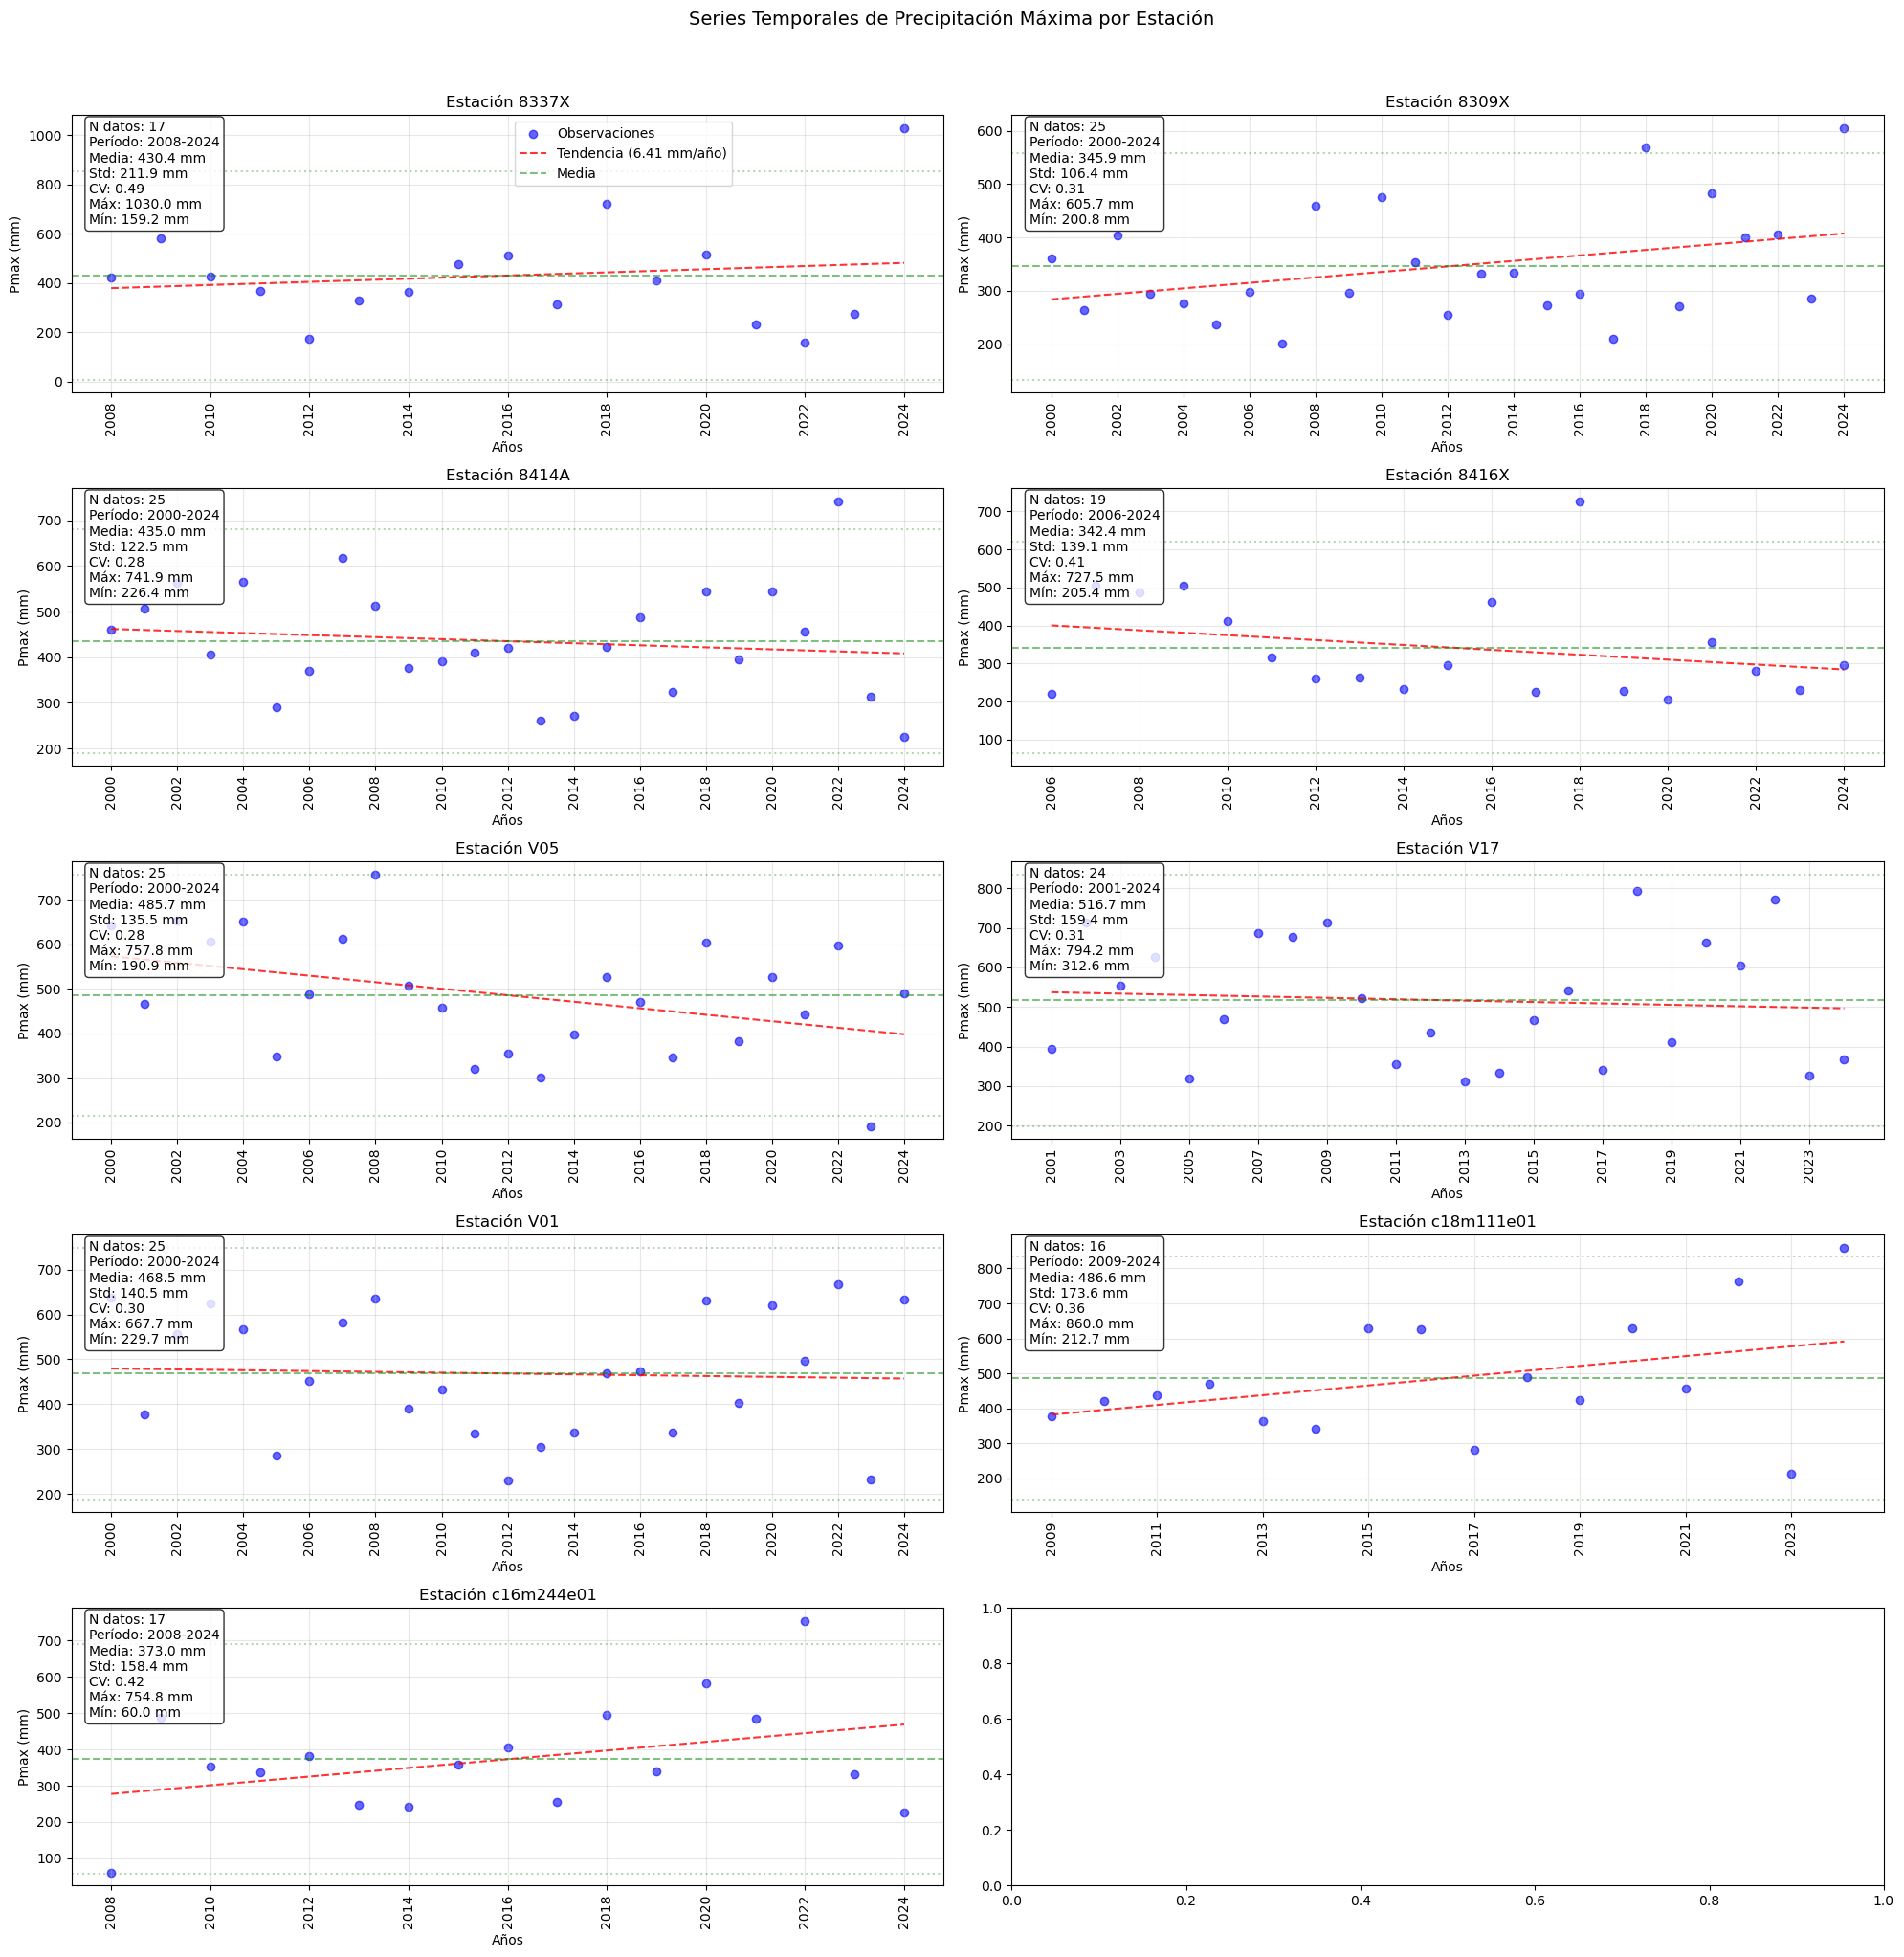

In [ ]:
# Crear visualización
fig, stats = plot_station_timeseries(Station_filter)


In [ ]:
stats


,Estación,N datos,Período,Media (mm),Std (mm),CV,Máximo (mm),Mínimo (mm),Tendencia (mm/año)
0,8337X,17,2008-2024,430.424,211.894,0.492,1030.00,159.20,6.410
1,8309X,25,2000-2024,345.872,106.426,0.308,605.70,200.80,5.147
2,8414A,25,2000-2024,435.008,122.547,0.282,741.90,226.40,-2.234
3,8416X,19,2006-2024,342.368,139.094,0.406,727.50,205.40,-6.443
4,V05,25,2000-2024,485.747,135.453,0.279,757.80,190.94,-7.310
5,V17,24,2001-2024,516.710,159.407,0.309,794.18,312.56,-1.773
6,V01,25,2000-2024,468.485,140.482,0.300,667.70,229.66,-0.928
7,c18m111e01,16,2009-2024,486.600,173.612,0.357,860.00,212.70,13.958
8,c16m244e01,17,2008-2024,373.006,158.363,0.425,754.80,60.00,11.963


# 2. Modelo Jerárquico

Se ejecutarán dos versiones del modelo jerárquico para comparar resultados: una incorporando los datos del evento DANA de Valencia 2024, y otra excluyendo estos registros. En ambos casos, se analizarán tanto los parámetros poblacionales como los específicos de cada distribución local, con especial énfasis en la evaluación del evento de 100 años de periodo de retorno. Esta estrategia permitirá evaluar la sensibilidad del modelo a eventos extremos recientes, cuantificar su impacto en la estructura jerárquica completa y valorar cómo la inclusión o exclusión de eventos extremos altera las estimaciones de eventos con baja probabilidad de ocurrencia.

In [156]:
Station_filter.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 25 entries, 2000-12-31 to 2024-12-31
Freq: A-DEC
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   8337X       17 non-null     float64
 1   8309X       25 non-null     float64
 2   8414A       25 non-null     float64
 3   8416X       19 non-null     float64
 4   V05         25 non-null     float64
 5   V17         24 non-null     float64
 6   V01         25 non-null     float64
 7   c18m111e01  16 non-null     float64
 8   c16m244e01  17 non-null     float64
dtypes: float64(9)
memory usage: 2.0 KB


## 2.1. Con evento **DANA**

In [157]:
# Asegurarse que los datos son float
Station_filter_copy = Station_filter.astype(float)

# Ajustar modelo
fit_all = fit_gev_hierarchical(Station_filter_copy)

# Extraer resultados
samples = fit_all.extract()

# Imprimir parámetros poblacionales
print("\nParámetros poblacionales (media ± desv. std):")
print(f"μ población: {np.mean(samples['mu_pop']):.2f} ± {np.std(samples['mu_pop']):.2f}")
print(f"σ población: {np.mean(samples['sigma_pop']):.2f} ± {np.std(samples['sigma_pop']):.2f}")
print(f"ξ población: {np.mean(samples['xi_pop']):.3f} ± {np.std(samples['xi_pop']):.3f}")

# Imprimir niveles de retorno para 100 años
print("\nNiveles de retorno para T=100 años:")
for i, station in enumerate(Station_filter_copy.columns):
    levels = samples['return_levels'][:,i,3]  # índice 3 corresponde a T=100
    mean = np.mean(levels)
    ci = np.percentile(levels, [2.5, 97.5])
    print(f"{station}: {mean:.1f} [{ci[0]:.1f}, {ci[1]:.1f}]")


INFO:pystan:COMPILING THE C++ CODE FOR MODEL anon_model_cbc183ee18b1cf115b71cef31c36d4a2 NOW.



Parámetros poblacionales (media ± desv. std):
μ población: 368.55 ± 21.95
σ población: 129.44 ± 10.79
ξ población: -0.074 ± 0.075

Niveles de retorno para T=100 años:
8337X: 994.8 [789.7, 1501.3]
8309X: 798.0 [595.5, 1268.9]
8414A: 853.0 [697.7, 1128.7]
8416X: 904.6 [651.8, 1674.6]
V05: 882.4 [731.5, 1126.3]
V17: 996.6 [797.8, 1504.7]
V01: 869.6 [684.6, 1146.2]
c18m111e01: 970.3 [786.6, 1384.4]
c16m244e01: 842.3 [685.9, 1136.8]


In [65]:
# Para ver los resultados de las estaciones individuales
fit_all['mu_station[1]'].mean(), fit_all['sigma_station[1]'].mean(), fit_all['xi_station[1]'].mean()


(345.67547273198994, 142.09140059038666, -0.02148165832939519)

Aquí visualizamos la distribución del evento de 100 años de periodo de retorno derivada directamente de los parámetros poblacionales del modelo jerárquico. Este gráfico representa una visión regional del riesgo, mostrando la distribución de probabilidad del evento centenario según las características comunes identificadas por el modelo para toda la zona de estudio. La media y los intervalos de credibilidad del 95% nos permiten cuantificar no solo la magnitud esperada de estos eventos extremos a nivel regional, sino también la incertidumbre asociada a esta estimación considerando la información del evento DANA 2024.


Estadísticas del período de retorno de 100 años (parámetros poblacionales):
Media: 881.63
Intervalo de credibilidad 95%: [744.57, 1095.50]


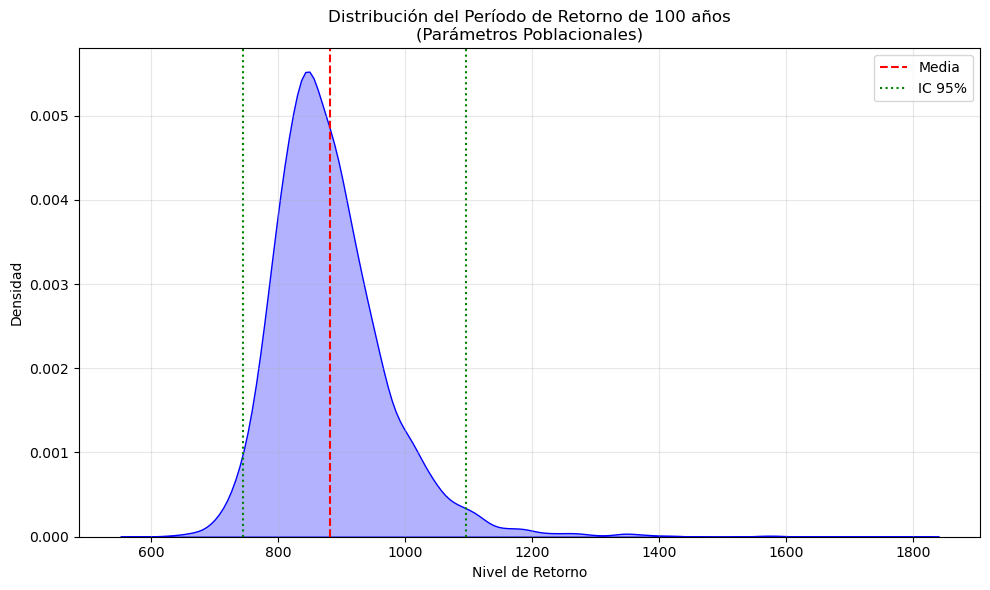

In [ ]:
# Extraer los parámetros poblacionales de las muestras MCMC
mu_pop_samples = samples['mu_pop']
sigma_pop_samples = samples['sigma_pop']
xi_pop_samples = samples['xi_pop']

# Función para calcular el nivel de retorno de 100 años
def return_level_100(mu, sigma, xi):
    p = 1 - 1/100  # probabilidad para T=100
    if abs(xi) > 1e-6:
        return mu + (sigma/xi) * (np.power(-np.log(p), -xi) - 1)
    else:
        return mu - sigma * np.log(-np.log(p))

# Calcular niveles de retorno para cada muestra MCMC
n_samples = len(mu_pop_samples)
return_levels_100 = np.zeros(n_samples)

for i in range(n_samples):
    return_levels_100[i] = return_level_100(
        mu_pop_samples[i], 
        sigma_pop_samples[i], 
        xi_pop_samples[i]
    )

# Crear el gráfico
plt.figure(figsize=(10, 6))

# Graficar KDE de los niveles de retorno
sns.kdeplot(data=return_levels_100, color='blue', fill=True, alpha=0.3)

# Añadir línea vertical con la media
mean_level = np.mean(return_levels_100)
ci_lower, ci_upper = np.percentile(return_levels_100, [2.5, 97.5])

plt.axvline(mean_level, color='red', linestyle='--', label='Media')
plt.axvline(ci_lower, color='green', linestyle=':', label='IC 95%')
plt.axvline(ci_upper, color='green', linestyle=':')

# Personalizar el gráfico
plt.title('Distribución del Período de Retorno de 100 años\n(Parámetros Poblacionales)')
plt.xlabel('Nivel de Retorno')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)

# Imprimir estadísticas
print(f"\nEstadísticas del período de retorno de 100 años (parámetros poblacionales):")
print(f"Media: {mean_level:.2f}")
print(f"Intervalo de credibilidad 95%: [{ci_lower:.2f}, {ci_upper:.2f}]")

plt.tight_layout();


Para comprender mejor las estimaciones de riesgo hidrológico, visualizamos las distribuciones de probabilidad del evento de 100 años de periodo de retorno para cada estación. Estos gráficos nos muestran tanto los valores medios esperados como la incertidumbre asociada (intervalos de confianza del 95%) para cada ubicación analizada. La comparación entre estaciones nos permite identificar diferencias en la magnitud y variabilidad de estas predicciones extremas según el modelo jerárquico que incluye los datos del evento DANA de Valencia 2024. Esta visualización constituye un primer paso para evaluar cómo las estimaciones de eventos extremos varían espacialmente en nuestra región de estudio.

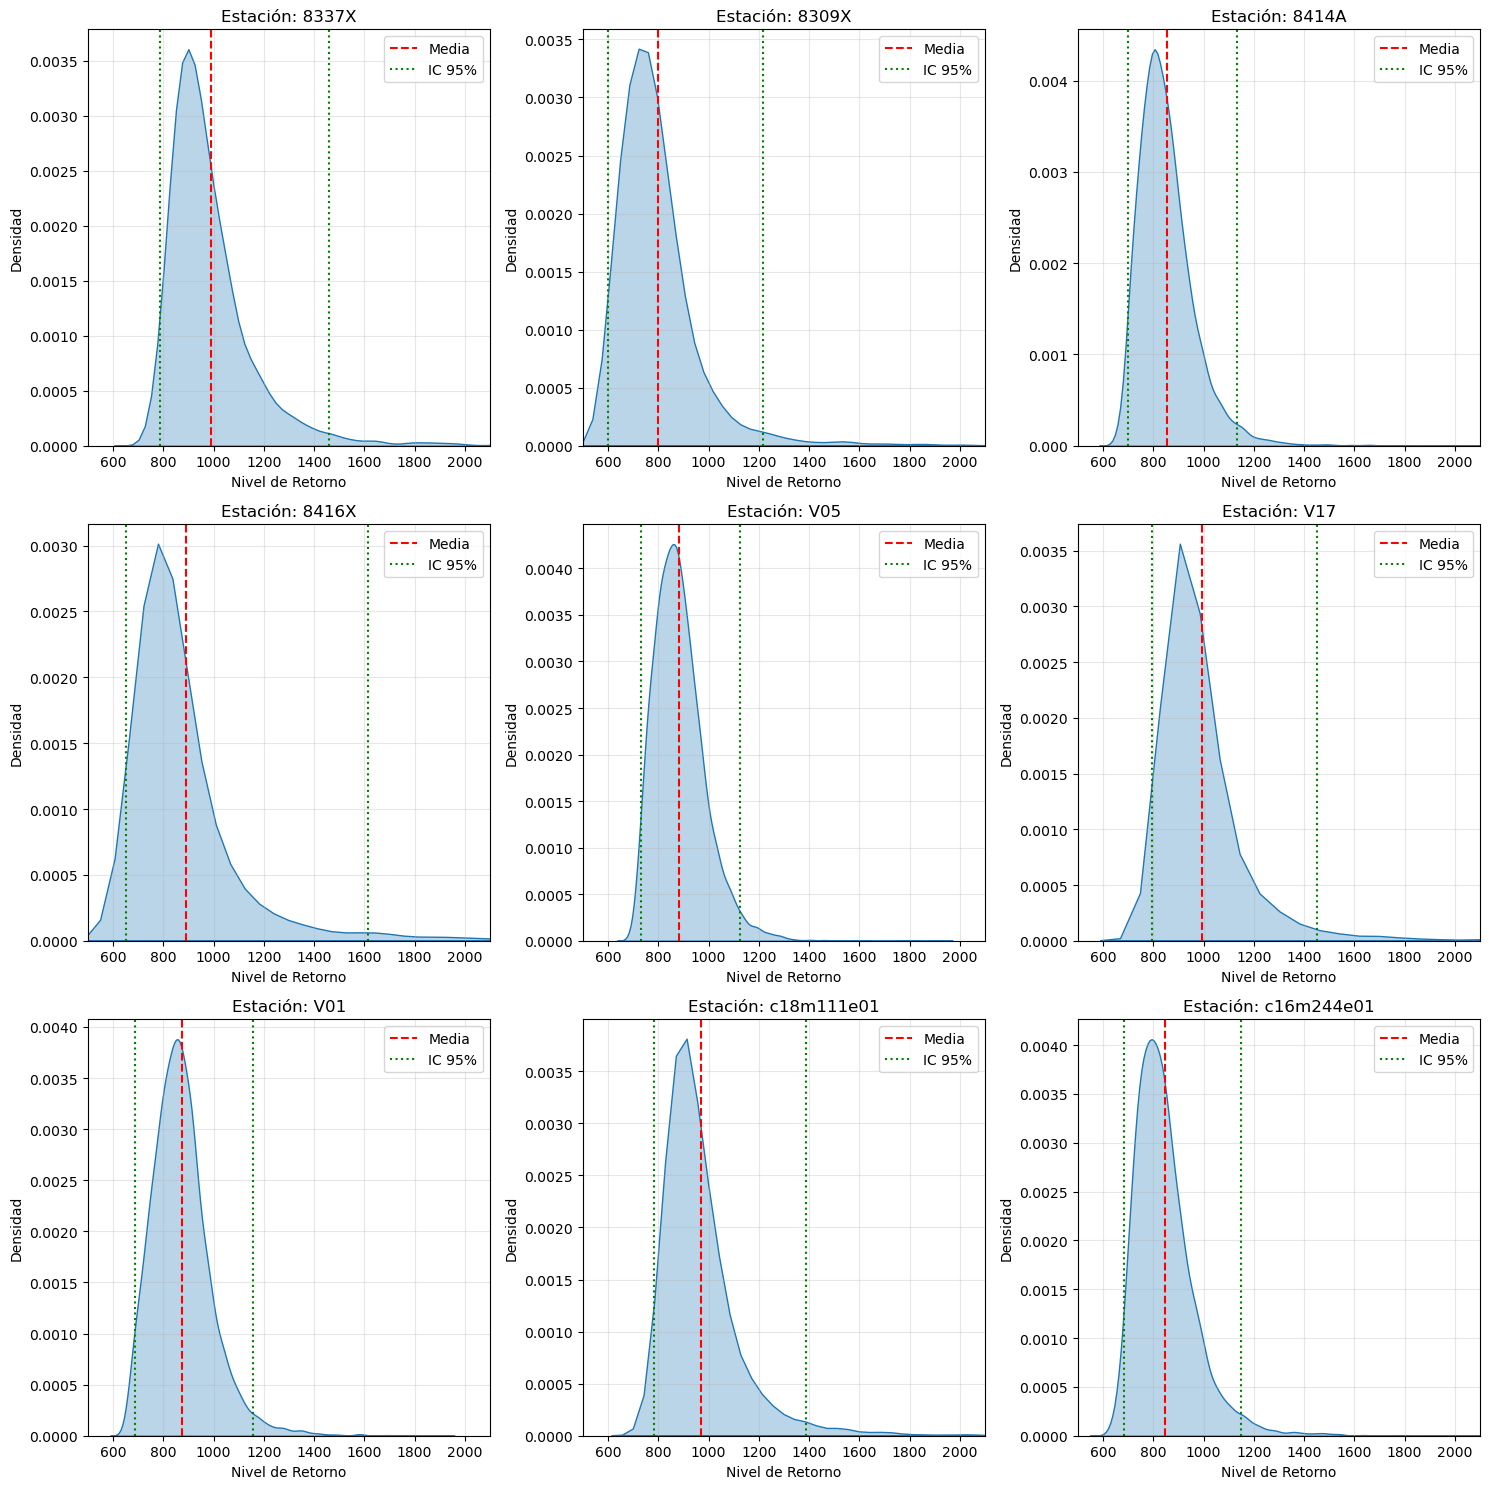

In [69]:
# Extraer los niveles de retorno de 100 años para todas las estaciones
levels_100 = samples['return_levels'][:,:,3]  # El índice 3 corresponde a T=100

# Calcular número de filas y columnas necesarias para el subplot
n_stations = len(Station_filter_copy.columns)
n_rows = 3
n_cols = 3

# Crear la figura con subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
axes = axes.flatten()  # Aplanar el array de axes para facilitar la iteración

# Graficar el KDE para cada estación en su propio subplot
for i, station in enumerate(Station_filter_copy.columns):
    if i < n_stations:
        # Calcular estadísticas para esta estación
        station_mean = np.mean(levels_100[:,i])
        station_ci = np.percentile(levels_100[:,i], [2.5, 97.5])
        
        # Crear el KDE plot
        sns.kdeplot(data=levels_100[:,i], ax=axes[i], fill=True, alpha=0.3)
        
        # Añadir líneas verticales para la media y CI
        axes[i].axvline(station_mean, color='red', linestyle='--', label='Media')
        axes[i].axvline(station_ci[0], color='green', linestyle=':', label='IC 95%')
        axes[i].axvline(station_ci[1], color='green', linestyle=':')
        
        # Personalizar cada subplot
        axes[i].set_title(f'Estación: {station}')
        axes[i].set_xlabel('Nivel de Retorno')
        axes[i].set_ylabel('Densidad')
        axes[i].set_xlim(500, 2100)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()

# Eliminar subplots vacíos si hay menos de 9 estaciones
for i in range(n_stations, n_rows * n_cols):
    fig.delaxes(axes[i])

# Ajustar el layout
plt.tight_layout()


## 2.2. Sin evento **DANA**

In [70]:
# Asegurarse que los datos son float
Station_filter_nu = Station_filter.loc[:'2023', :]

# Ajustar modelo
fit_nu = fit_gev_hierarchical(Station_filter_nu)

# Extraer resultados
samples_ = fit_nu.extract()

# Imprimir parámetros poblacionales
print("\nParámetros poblacionales (media ± desv. std):")
print(f"μ población: {np.mean(samples_['mu_pop']):.2f} ± {np.std(samples_['mu_pop']):.2f}")
print(f"σ población: {np.mean(samples_['sigma_pop']):.2f} ± {np.std(samples_['sigma_pop']):.2f}")
print(f"ξ población: {np.mean(samples_['xi_pop']):.3f} ± {np.std(samples_['xi_pop']):.3f}")

# Imprimir niveles de retorno para 100 años
print("\nNiveles de retorno para T=100 años:")
for i, station in enumerate(Station_filter_nu.columns):
    levels = samples_['return_levels'][:,i,3]  # índice 3 corresponde a T=100
    mean = np.mean(levels)
    ci = np.percentile(levels, [2.5, 97.5])
    print(f"{station}: {mean:.1f} [{ci[0]:.1f}, {ci[1]:.1f}]")


INFO:pystan:COMPILING THE C++ CODE FOR MODEL anon_model_cbc183ee18b1cf115b71cef31c36d4a2 NOW.



Parámetros poblacionales (media ± desv. std):
μ población: 370.74 ± 21.90
σ población: 127.29 ± 10.76
ξ población: -0.138 ± 0.071

Niveles de retorno para T=100 años:
8337X: 805.2 [669.1, 1065.4]
8309X: 701.9 [551.9, 954.0]
8414A: 810.3 [688.8, 1035.4]
8416X: 797.9 [638.2, 1176.6]
V05: 846.4 [725.8, 1049.2]
V17: 921.1 [781.1, 1247.4]
V01: 825.4 [688.0, 1039.2]
c18m111e01: 851.0 [717.7, 1116.8]
c16m244e01: 802.3 [674.5, 1043.5]


In [71]:
fit_nu['mu_station[1]'].mean(), fit_nu['sigma_station[1]'].mean(), fit_nu['xi_station[1]'].mean()


(343.9851095257876, 132.7008477957906, -0.13893532876908926)

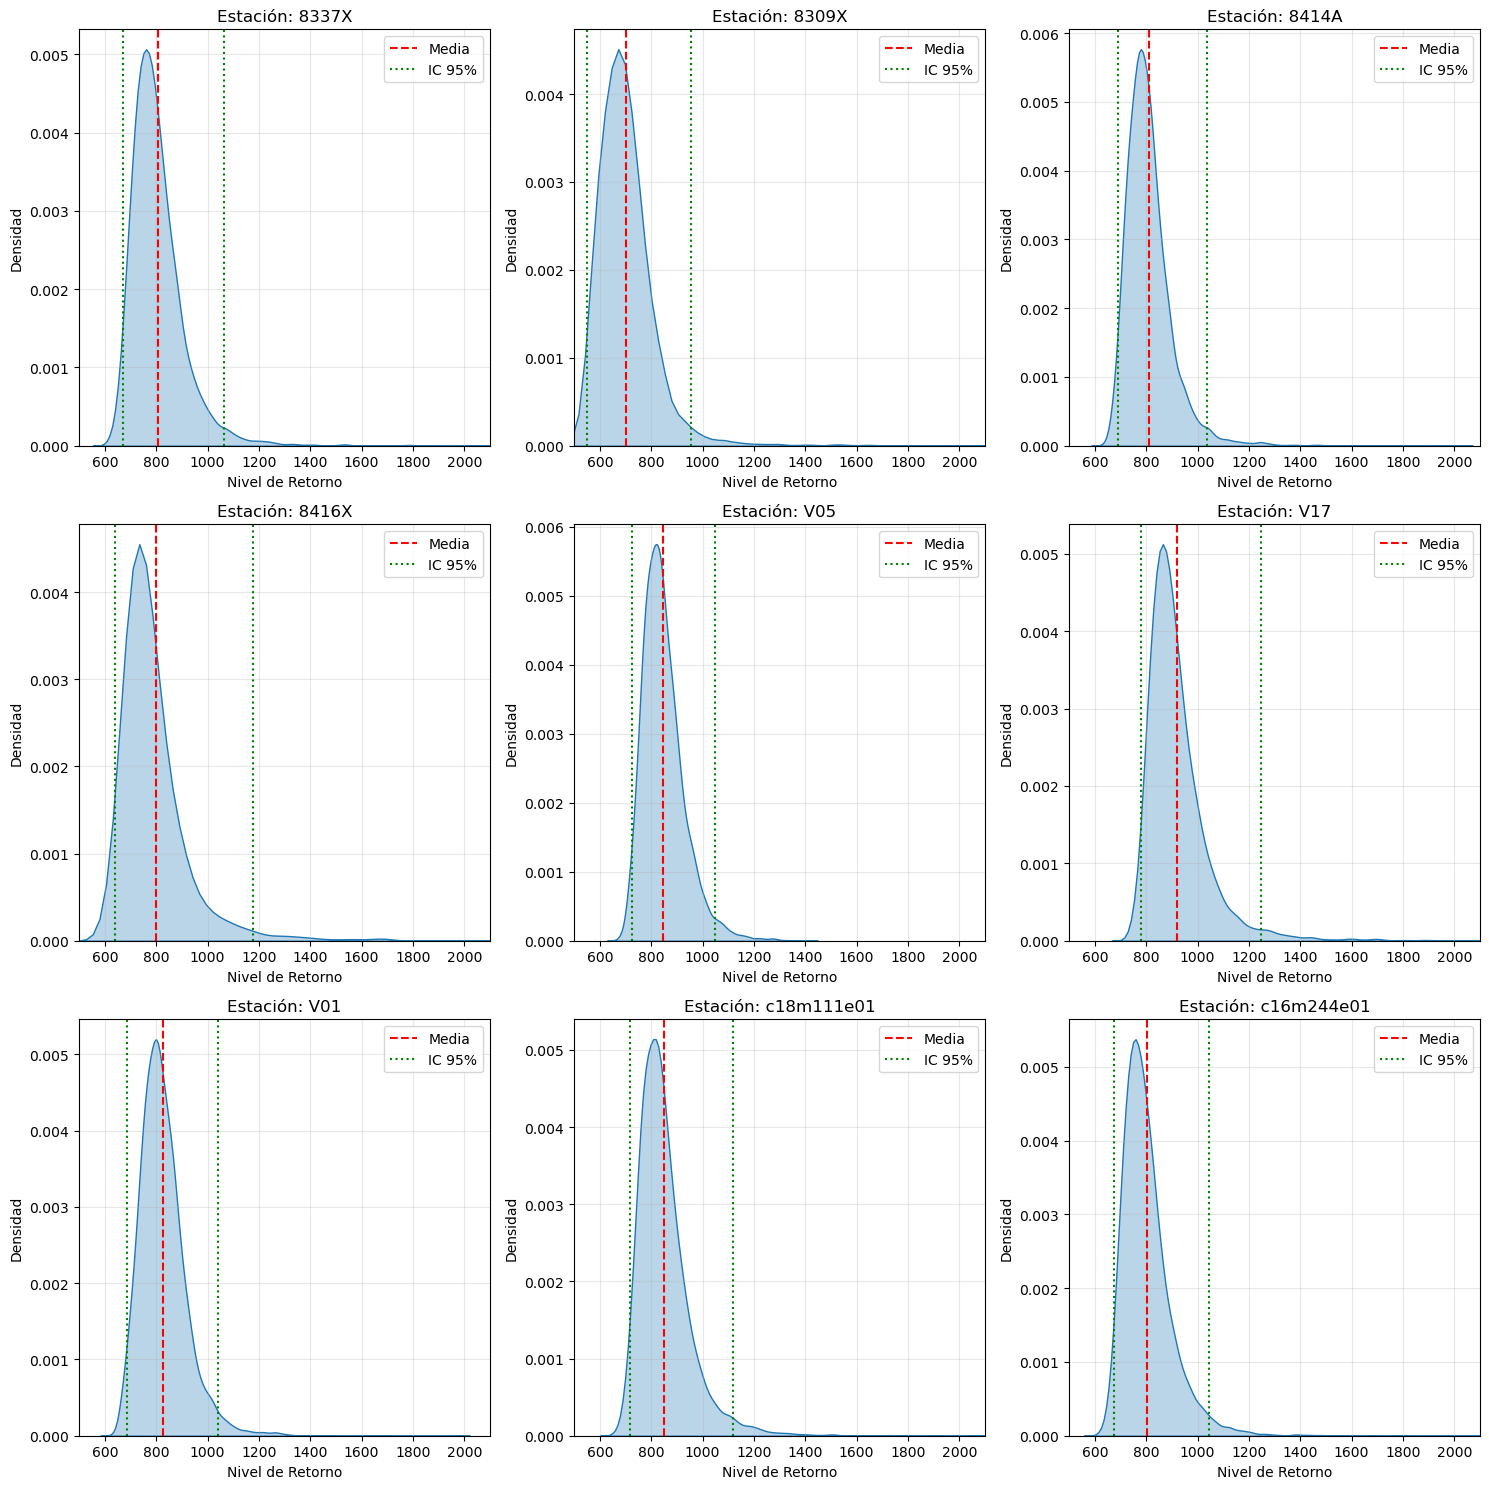

In [ ]:
# Extraer los niveles de retorno de 100 años para todas las estaciones
levels_100 = samples_['return_levels'][:,:,3]  # El índice 3 corresponde a T=100

# Calcular número de filas y columnas necesarias para el subplot
n_stations = len(Station_filter_copy.columns)
n_rows = 3
n_cols = 3

# Crear la figura con subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
axes = axes.flatten()  # Aplanar el array de axes para facilitar la iteración

# Graficar el KDE para cada estación en su propio subplot
for i, station in enumerate(Station_filter_copy.columns):
    if i < n_stations:
        # Calcular estadísticas para esta estación
        station_mean = np.mean(levels_100[:,i])
        station_ci = np.percentile(levels_100[:,i], [2.5, 97.5])
        
        # Crear el KDE plot
        sns.kdeplot(data=levels_100[:,i], ax=axes[i], fill=True, alpha=0.3)
        
        # Añadir líneas verticales para la media y CI
        axes[i].axvline(station_mean, color='red', linestyle='--', label='Media')
        axes[i].axvline(station_ci[0], color='green', linestyle=':', label='IC 95%')
        axes[i].axvline(station_ci[1], color='green', linestyle=':')
        
        # Personalizar cada subplot
        axes[i].set_title(f'Estación: {station}')
        axes[i].set_xlabel('Nivel de Retorno')
        axes[i].set_ylabel('Densidad')
        axes[i].set_xlim(500, 2100)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()

# Eliminar subplots vacíos si hay menos de 9 estaciones
for i in range(n_stations, n_rows * n_cols):
    fig.delaxes(axes[i])

# Ajustar el layout
plt.tight_layout()


# 3. Análisis comparativo 

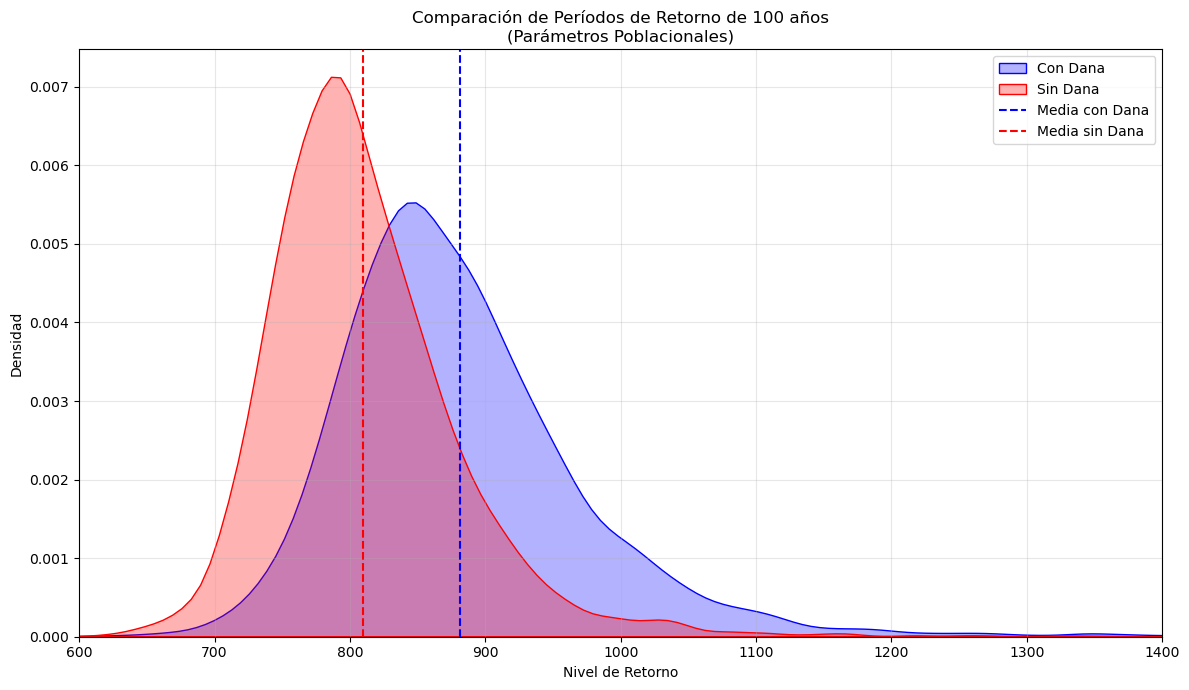

In [ ]:
# Función para calcular el nivel de retorno de 100 años
def return_level_100(mu, sigma, xi):
    p = 1 - 1/100  # probabilidad para T=100
    if abs(xi) > 1e-6:
        return mu + (sigma/xi) * (np.power(-np.log(p), -xi) - 1)
    else:
        return mu - sigma * np.log(-np.log(p))

# Calcular niveles de retorno para el primer conjunto (samples)
mu_pop_samples1 = samples['mu_pop']
sigma_pop_samples1 = samples['sigma_pop']
xi_pop_samples1 = samples['xi_pop']

n_samples1 = len(mu_pop_samples1)
return_levels_100_1 = np.zeros(n_samples1)

for i in range(n_samples1):
    return_levels_100_1[i] = return_level_100(
        mu_pop_samples1[i], 
        sigma_pop_samples1[i], 
        xi_pop_samples1[i]
    )

# Calcular niveles de retorno para el segundo conjunto (samples_)
mu_pop_samples2 = samples_['mu_pop']
sigma_pop_samples2 = samples_['sigma_pop']
xi_pop_samples2 = samples_['xi_pop']

n_samples2 = len(mu_pop_samples2)
return_levels_100_2 = np.zeros(n_samples2)

for i in range(n_samples2):
    return_levels_100_2[i] = return_level_100(
        mu_pop_samples2[i], 
        sigma_pop_samples2[i], 
        xi_pop_samples2[i]
    )

# Crear el gráfico
plt.figure(figsize=(12, 7))

# Graficar KDE de los niveles de retorno para ambos conjuntos
sns.kdeplot(data=return_levels_100_1, color='blue', fill=True, alpha=0.3, label='Con Dana')
sns.kdeplot(data=return_levels_100_2, color='red', fill=True, alpha=0.3, label='Sin Dana')

# Añadir líneas verticales con las medias y CI para ambos modelos
mean_level1 = np.mean(return_levels_100_1)
ci_lower1, ci_upper1 = np.percentile(return_levels_100_1, [2.5, 97.5])

mean_level2 = np.mean(return_levels_100_2)
ci_lower2, ci_upper2 = np.percentile(return_levels_100_2, [2.5, 97.5])

# Líneas para Modelo 1
plt.axvline(mean_level1, color='blue', linestyle='--', label='Media con Dana')
#plt.axvline(ci_lower1, color='blue', linestyle=':', alpha=0.5)
#plt.axvline(ci_upper1, color='blue', linestyle=':', alpha=0.5)

# Líneas para Modelo 2
plt.axvline(mean_level2, color='red', linestyle='--', label='Media sin Dana')
plt.xlim(600, 1400)
#plt.axvline(ci_lower2, color='red', linestyle=':', alpha=0.5)
#plt.axvline(ci_upper2, color='red', linestyle=':', alpha=0.5)

# Personalizar el gráfico
plt.title('Comparación de Períodos de Retorno de 100 años\n(Parámetros Poblacionales)')
plt.xlabel('Nivel de Retorno')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Comparación de parámetros poblacionales

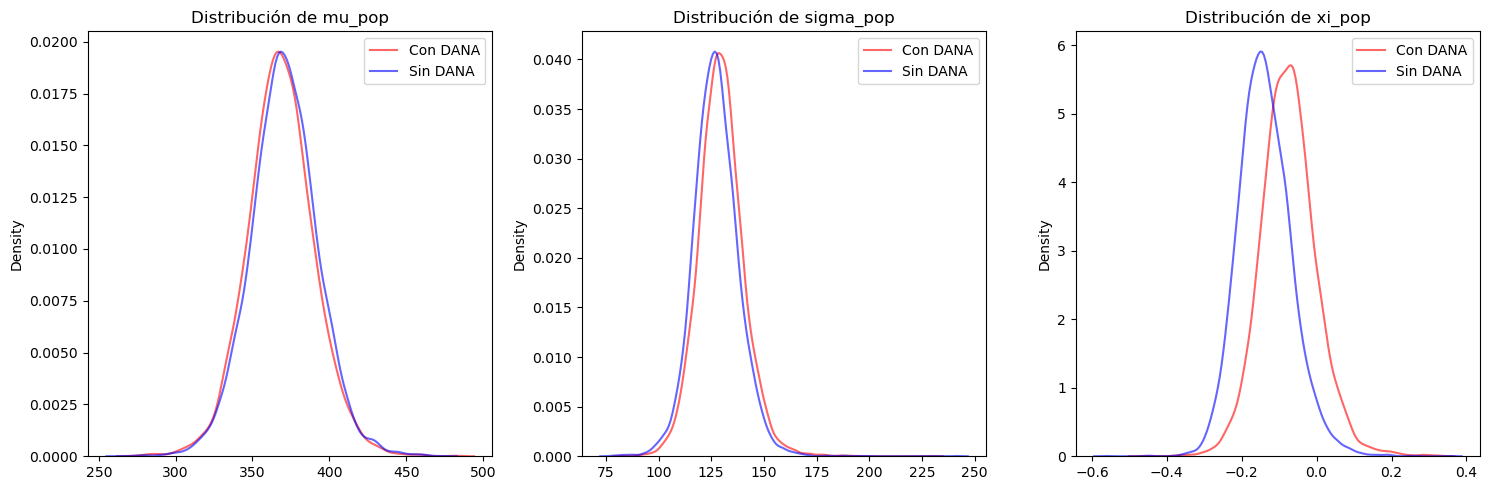

In [ ]:
stations = Station_filter.columns  # O Station_filter_nu.columns
# Generar los gráficos
fig1 = plot_population_parameters_comparison(samples, samples_)


Comparación de niveles de retorno entre estaciones 

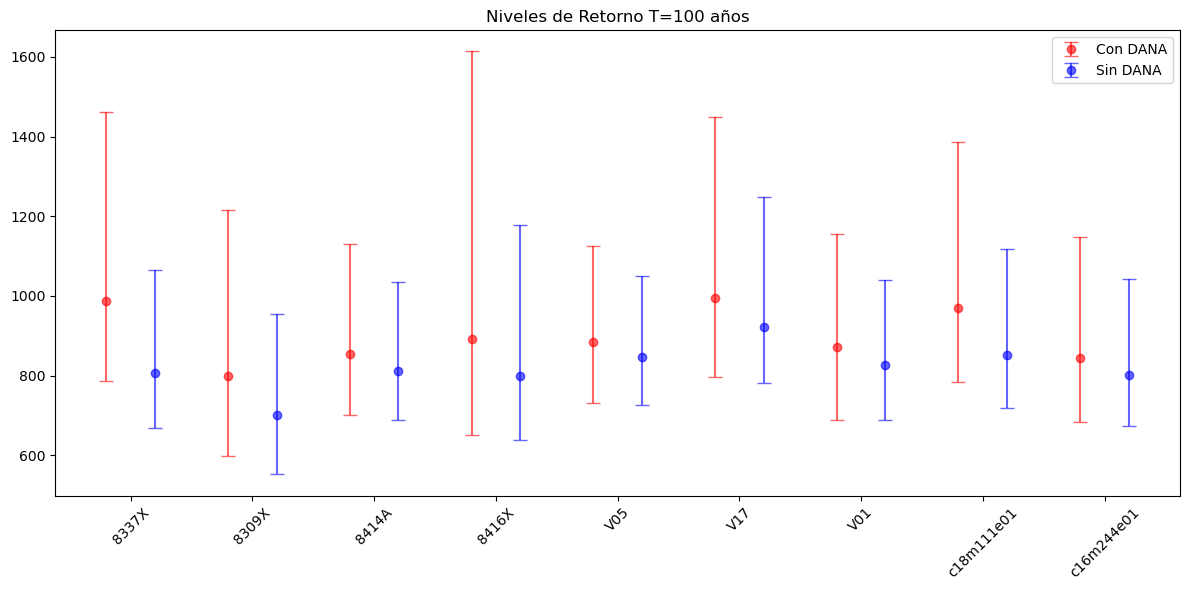

In [ ]:
fig2 = plot_return_levels_comparison(samples, samples_, stations)


## Pruebas

In [ ]:
from scipy.stats import genextreme


In [146]:
def fit_Parametric_gev(data):
    """
    Ajusta GEV Parametric a cada estación.
    """
    results = {}
    for col in data.columns:
        station_data = data[col].dropna()
        params = genextreme.fit(station_data)
        # Cambiar signo de xi para coincidir con parametrización Stan
        results[col] = {
            'shape': -params[0],  # Cambio de signo para coincidir con Stan
            'loc': params[1],
            'scale': params[2]
        }
    return results


In [147]:
def compare_gev_approaches(fit_all, fit_nu, station_names, data_all, data_nu):
    """
    Compara GEV regional (con/sin DANA) vs GEV Parametric.
    """
    # Extraer muestras
    samples_all = fit_all.extract()
    samples_nu = fit_nu.extract()
    
    # Ajustar GEV Parametric para ambos casos
    Parametric_fits_all = fit_Parametric_gev(data_all)
    Parametric_fits_nu = fit_Parametric_gev(data_nu)
    
    # Preparar datos para el plot
    plot_data = []
    
    params = {
        'mu': 'Localización (μ)',
        'sigma': 'Escala (σ)',
        'xi': 'Forma (ξ)'
    }
    
    # Imprimir parámetros globales primero
    print("\nParámetros Globales:")
    print("\nCon DANA:")
    print(f"μ población: {np.mean(samples_all['mu_pop']):.2f} ± {np.std(samples_all['mu_pop']):.2f}")
    print(f"σ población: {np.mean(samples_all['sigma_pop']):.2f} ± {np.std(samples_all['sigma_pop']):.2f}")
    print(f"ξ población: {np.mean(samples_all['xi_pop']):.3f} ± {np.std(samples_all['xi_pop']):.3f}")
    
    print("\nSin DANA:")
    print(f"μ población: {np.mean(samples_nu['mu_pop']):.2f} ± {np.std(samples_nu['mu_pop']):.2f}")
    print(f"σ población: {np.mean(samples_nu['sigma_pop']):.2f} ± {np.std(samples_nu['sigma_pop']):.2f}")
    print(f"ξ población: {np.mean(samples_nu['xi_pop']):.3f} ± {np.std(samples_nu['xi_pop']):.3f}")
    
    # Extraer muestras para modelos regionales
    for i, station in enumerate(station_names):
        for param_key, param_label in params.items():
            # Regional con DANA
            param_all = samples_all[f'{param_key}_station'][:,i]
            for value in param_all:
                plot_data.append({
                    'Estación': station,
                    'Parámetro': param_label,
                    'Valor': value,
                    'Modelo': 'Regional con DANA'
                })
            
            # Regional sin DANA
            param_nu = samples_nu[f'{param_key}_station'][:,i]
            for value in param_nu:
                plot_data.append({
                    'Estación': station,
                    'Parámetro': param_label,
                    'Valor': value,
                    'Modelo': 'Regional sin DANA'
                })
            
            # Añadir parámetros globales como una "estación" especial
            if i == 0:  # Solo una vez
                for value in samples_all[f'{param_key}_pop']:
                    plot_data.append({
                        'Estación': 'Global',
                        'Parámetro': param_label,
                        'Valor': value,
                        'Modelo': 'Regional con DANA'
                    })
                for value in samples_nu[f'{param_key}_pop']:
                    plot_data.append({
                        'Estación': 'Global',
                        'Parámetro': param_label,
                        'Valor': value,
                        'Modelo': 'Regional sin DANA'
                    })
    
    # Crear figura
    fig, axs = plt.subplots(3, 1, figsize=(15, 20))
    plt.subplots_adjust(hspace=0.3)
    
    param_map = {'Localización (μ)': 'loc', 
                 'Escala (σ)': 'scale', 
                 'Forma (ξ)': 'shape'}
    
    # Colores para cada modelo
    colors = {'Regional con DANA': 'lightblue',
              'Regional sin DANA': 'lightgreen',
              'Parametric con DANA': 'b',
              'Parametric sin DANA': 'g'}
    
    df = pd.DataFrame(plot_data)
    
    # En la parte donde se crean los plots, dentro del loop de parámetros
    for i, (param_name, param_label) in enumerate(params.items()):
        # Subset de datos para este parámetro
        df_param = df[df['Parámetro'] == param_label]
        
        # Crear boxplot
        sns.boxplot(data=df_param, x='Estación', y='Valor', 
                   hue='Modelo', ax=axs[i],
                   palette=[colors['Regional con DANA'], 
                           colors['Regional sin DANA']])
        
        # Añadir líneas horizontales para los parámetros globales
        if param_name == 'mu':
            global_param_all = np.mean(samples_all['mu_pop'])
            global_param_nu = np.mean(samples_nu['mu_pop'])
        elif param_name == 'sigma':
            global_param_all = np.mean(samples_all['sigma_pop'])
            global_param_nu = np.mean(samples_nu['sigma_pop'])
        else:  # xi
            global_param_all = np.mean(samples_all['xi_pop'])
            global_param_nu = np.mean(samples_nu['xi_pop'])
        
        # Añadir líneas horizontales
        axs[i].axhline(y=global_param_all, color=colors['Regional con DANA'], 
                      linestyle='--', alpha=0.8, 
                      label='Global con DANA')
        axs[i].axhline(y=global_param_nu, color=colors['Regional sin DANA'], 
                      linestyle='--', alpha=0.8,
                      label='Global sin DANA')
        
        # Añadir puntos para GEV individual (con DANA)
        for j, station in enumerate(station_names):
            if station != 'Global':
                indiv_value = Parametric_fits_all[station][param_map[param_label]]
                axs[i].scatter(j+1, indiv_value, color=colors['Parametric con DANA'], 
                             s=100, marker='*', label='Parametric con DANA' if j==0 else "")
                
                # Añadir puntos para GEV individual (sin DANA)
                indiv_value_nu = Parametric_fits_nu[station][param_map[param_label]]
                axs[i].scatter(j+1, indiv_value_nu, color=colors['Parametric sin DANA'], 
                             s=100, marker='o', label='Parametric sin DANA' if j==0 else "")
        
        # Personalizar plot
        axs[i].set_title(f'Distribución de {param_label} por estación', pad=20)
        axs[i].set_xlabel('Estación')
        axs[i].set_ylabel(param_label)
        axs[i].grid(True, alpha=0.3)
        
        # Rotar etiquetas
        axs[i].tick_params(axis='x', rotation=45)
        
        # Ajustar leyenda
        if i == 2:  # Solo para el último plot
            handles, labels = axs[i].get_legend_handles_labels()
            handles.extend([
                plt.Line2D([0], [0], marker='*', color='b', 
                          markerfacecolor=colors['Parametric con DANA'], 
                          markersize=10, label='Parametric con DANA'),
                plt.Line2D([0], [0], marker='o', color='g', 
                          markerfacecolor=colors['Parametric sin DANA'], 
                          markersize=10, label='Parametric sin DANA')
            ])
            axs[i].legend(handles=handles, title='', ncol=4)
        else:
            axs[i].get_legend().remove()
    
    plt.suptitle('Comparación de GEV Regional vs Parametric\nCon y Sin DANA', 
                y=1.02, fontsize=16)
    
    # Ajustar layout
    plt.tight_layout()
    
    # Imprimir estadísticas comparativas
    print("\nComparación de estimaciones por estación:")
    for station in station_names:
        if station != 'Global':  # Skip Global for individual comparisons
            i = list(station_names).index(station)
            print(f"\n{station}:")
            print("Regional con DANA (media ± std):")
            print(f"  μ: {samples_all['mu_station'][:,i].mean():.2f} ± {samples_all['mu_station'][:,i].std():.2f}")
            print(f"  σ: {samples_all['sigma_station'][:,i].mean():.2f} ± {samples_all['sigma_station'][:,i].std():.2f}")
            print(f"  ξ: {samples_all['xi_station'][:,i].mean():.3f} ± {samples_all['xi_station'][:,i].std():.3f}")
            
            print("Regional sin DANA (media ± std):")
            print(f"  μ: {samples_nu['mu_station'][:,i].mean():.2f} ± {samples_nu['mu_station'][:,i].std():.2f}")
            print(f"  σ: {samples_nu['sigma_station'][:,i].mean():.2f} ± {samples_nu['sigma_station'][:,i].std():.2f}")
            print(f"  ξ: {samples_nu['xi_station'][:,i].mean():.3f} ± {samples_nu['xi_station'][:,i].std():.3f}")
            
            print("Individual con DANA:")
            print(f"  μ: {Parametric_fits_all[station]['loc']:.2f}")
            print(f"  σ: {Parametric_fits_all[station]['scale']:.2f}")
            print(f"  ξ: {Parametric_fits_all[station]['shape']:.3f}")
            
            print("Individual sin DANA:")
            print(f"  μ: {Parametric_fits_nu[station]['loc']:.2f}")
            print(f"  σ: {Parametric_fits_nu[station]['scale']:.2f}")
            print(f"  ξ: {Parametric_fits_nu[station]['shape']:.3f}")
    
    return fig, df, Parametric_fits_all, Parametric_fits_nu



Parámetros Globales:

Con DANA:
μ población: 41.94 ± 3.43
σ población: 18.57 ± 2.65
ξ población: 0.377 ± 0.084

Sin DANA:
μ población: 41.72 ± 3.67
σ población: 16.78 ± 2.88
ξ población: 0.205 ± 0.085

Comparación de estimaciones por estación:

8337X:
Regional con DANA (media ± std):
  μ: 49.22 ± 5.13
  σ: 20.89 ± 4.39
  ξ: 0.439 ± 0.127
Regional sin DANA (media ± std):
  μ: 50.26 ± 5.30
  σ: 20.08 ± 4.39
  ξ: 0.230 ± 0.126
Individual con DANA:
  μ: 55.14
  σ: 25.00
  ξ: 0.666
Individual sin DANA:
  μ: 56.11
  σ: 21.74
  ξ: 0.215

8309X:
Regional con DANA (media ± std):
  μ: 33.77 ± 3.14
  σ: 14.89 ± 3.00
  ξ: 0.381 ± 0.106
Regional sin DANA (media ± std):
  μ: 31.89 ± 2.52
  σ: 11.63 ± 2.24
  ξ: 0.168 ± 0.120
Individual con DANA:
  μ: 30.33
  σ: 10.43
  ξ: 0.338
Individual sin DANA:
  μ: 30.47
  σ: 9.06
  ξ: 0.058

9531Y:
Regional con DANA (media ± std):
  μ: 40.95 ± 3.57
  σ: 17.01 ± 3.14
  ξ: 0.362 ± 0.121
Regional sin DANA (media ± std):
  μ: 39.64 ± 3.51
  σ: 14.47 ± 2.99
  ξ: 0.

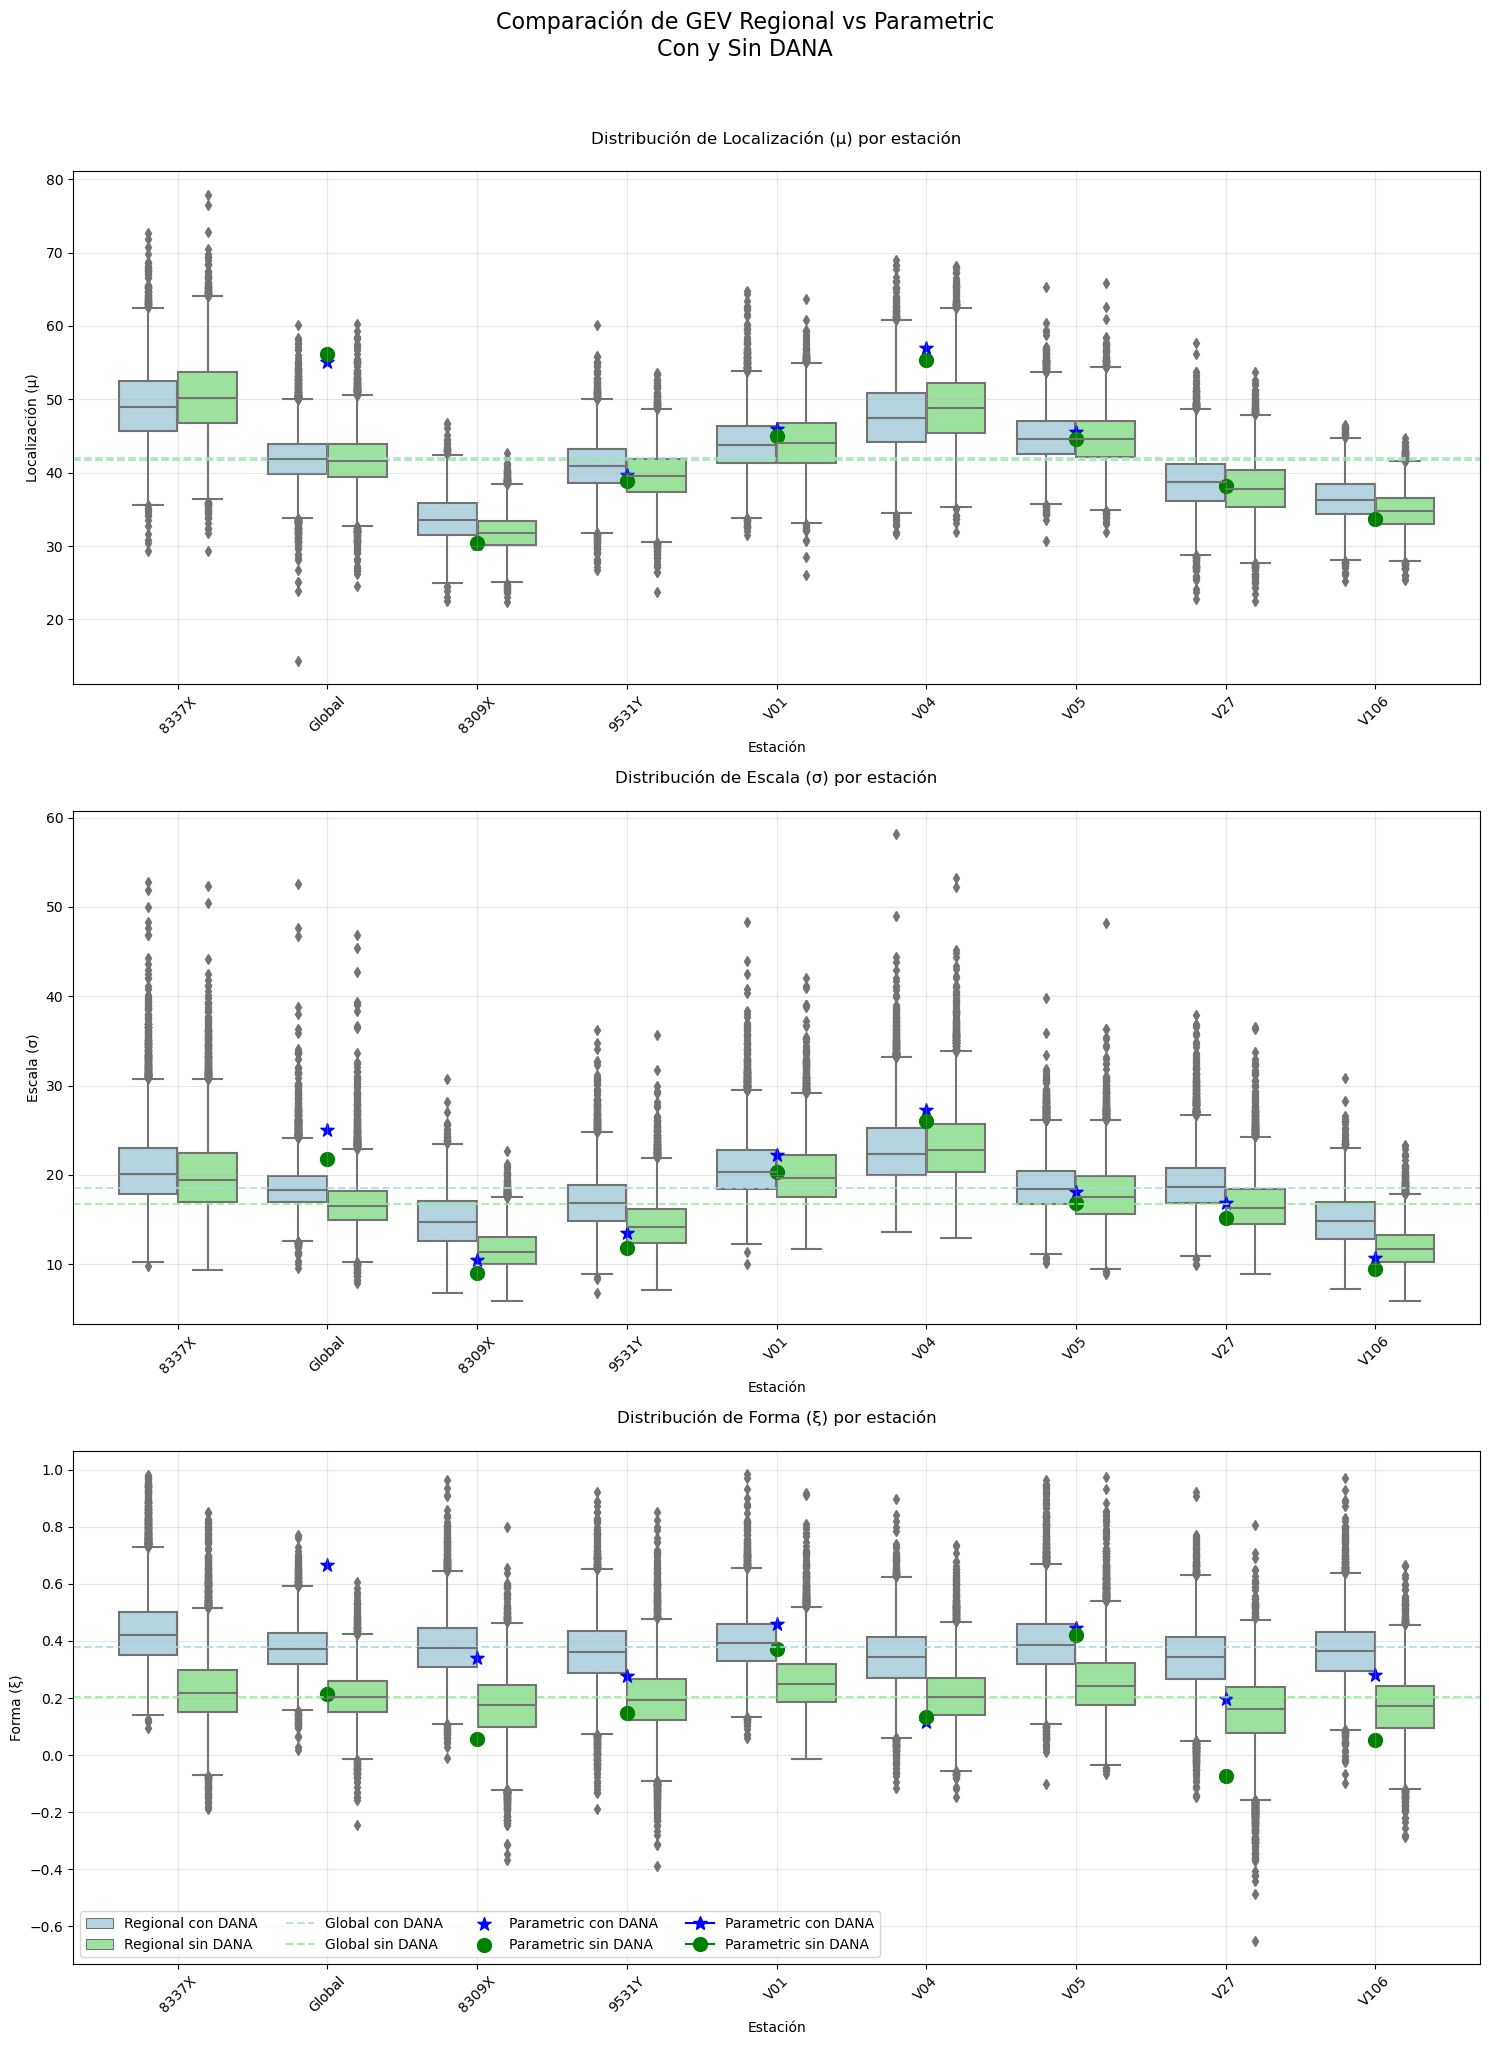

In [ ]:
# Ejemplo de uso
if __name__ == "__main__":
    fig, df_comparison, individual_fits_all, individual_fits_nu = compare_gev_approaches(
        fit_all, fit_nu, Station_filter.columns, Station_filter, Station_filter_nu)
    plt.show()


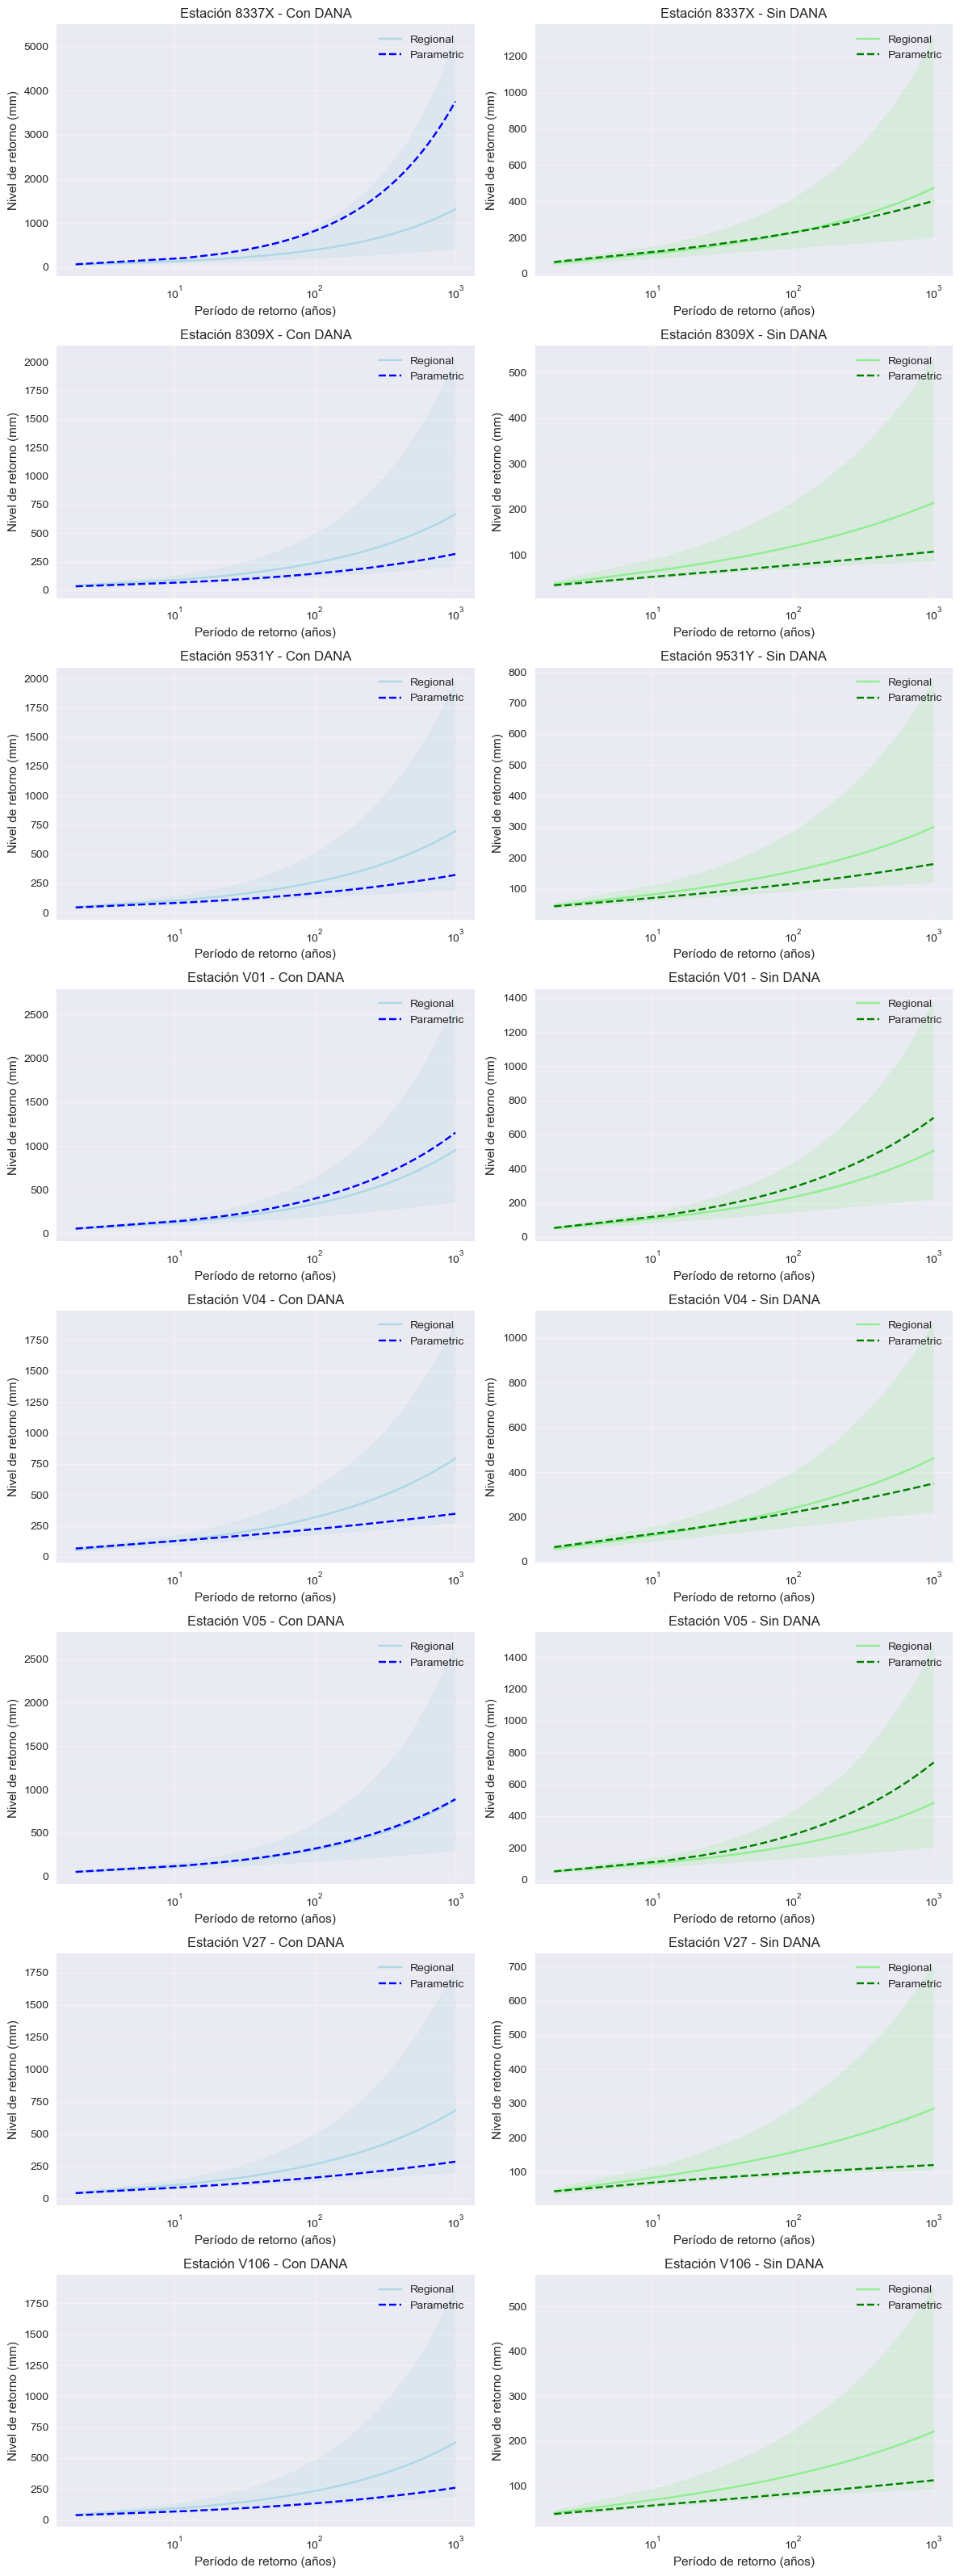

In [ ]:
def plot_return_period_station_comparison(fit_all, fit_nu, individual_fits_all, individual_fits_nu, station_names):
    """
    Genera plots lado a lado para cada estación.
    """
    n_stations = len(station_names)
    
    # Crear una figura con subplots para cada estación
    fig, axs = plt.subplots(n_stations, 2, figsize=(12, 4*n_stations))
    
    # Definir períodos de retorno
    return_periods = np.linspace(2, 1000, 100)
    probs = 1 - 1/return_periods
    
    # Colores que coinciden con el gráfico original
    colors = {
        'Regional con DANA': 'lightblue',
        'Regional sin DANA': 'lightgreen',
        'Parametric con DANA': 'blue',
        'Parametric sin DANA': 'green'
    }
    
    for idx, station in enumerate(station_names):
        # Plot con DANA
        ax_dana = axs[idx, 0]
        # Bayesiano con DANA
        mu_samples = fit_all[f'mu_station[{idx+1}]']
        sigma_samples = fit_all[f'sigma_station[{idx+1}]']
        xi_samples = fit_all[f'xi_station[{idx+1}]']
        
        levels_bayes = np.zeros((len(mu_samples), len(return_periods)))
        for i in range(len(mu_samples)):
            if abs(xi_samples[i]) > 1e-6:
                levels_bayes[i] = mu_samples[i] + (sigma_samples[i]/xi_samples[i]) * \
                                 ((-np.log(probs))**(-xi_samples[i]) - 1)
            else:
                levels_bayes[i] = mu_samples[i] - sigma_samples[i] * np.log(-np.log(probs))
        
        mean_levels = np.mean(levels_bayes, axis=0)
        ci_lower = np.percentile(levels_bayes, 2.5, axis=0)
        ci_upper = np.percentile(levels_bayes, 97.5, axis=0)
        
        ax_dana.plot(return_periods, mean_levels, '-', color=colors['Regional con DANA'],
                    label='Regional')
        ax_dana.fill_between(return_periods, ci_lower, ci_upper, 
                           color=colors['Regional con DANA'], alpha=0.2)
        
        # Paramétrico con DANA
        params = individual_fits_all[station]
        if abs(params['shape']) > 1e-6:
            levels_param = params['loc'] + (params['scale']/params['shape']) * \
                          ((-np.log(probs))**(-params['shape']) - 1)
        else:
            levels_param = params['loc'] - params['scale'] * np.log(-np.log(probs))
        
        ax_dana.plot(return_periods, levels_param, '--', color=colors['Parametric con DANA'],
                    label='Parametric')
        
        # Plot sin DANA
        ax_no_dana = axs[idx, 1]
        # Bayesiano sin DANA
        mu_samples = fit_nu[f'mu_station[{idx+1}]']
        sigma_samples = fit_nu[f'sigma_station[{idx+1}]']
        xi_samples = fit_nu[f'xi_station[{idx+1}]']
        
        levels_bayes = np.zeros((len(mu_samples), len(return_periods)))
        for i in range(len(mu_samples)):
            if abs(xi_samples[i]) > 1e-6:
                levels_bayes[i] = mu_samples[i] + (sigma_samples[i]/xi_samples[i]) * \
                                 ((-np.log(probs))**(-xi_samples[i]) - 1)
            else:
                levels_bayes[i] = mu_samples[i] - sigma_samples[i] * np.log(-np.log(probs))
        
        mean_levels = np.mean(levels_bayes, axis=0)
        ci_lower = np.percentile(levels_bayes, 2.5, axis=0)
        ci_upper = np.percentile(levels_bayes, 97.5, axis=0)
        
        ax_no_dana.plot(return_periods, mean_levels, '-', color=colors['Regional sin DANA'],
                       label='Regional')
        ax_no_dana.fill_between(return_periods, ci_lower, ci_upper, 
                              color=colors['Regional sin DANA'], alpha=0.2)
        
        # Paramétrico sin DANA
        params = individual_fits_nu[station]
        if abs(params['shape']) > 1e-6:
            levels_param = params['loc'] + (params['scale']/params['shape']) * \
                          ((-np.log(probs))**(-params['shape']) - 1)
        else:
            levels_param = params['loc'] - params['scale'] * np.log(-np.log(probs))
        
        ax_no_dana.plot(return_periods, levels_param, '--', color=colors['Parametric sin DANA'],
                       label='Parametric')
        
        # Configurar gráficos
        for ax, title in [(ax_dana, f'Estación {station} - Con DANA'), 
                         (ax_no_dana, f'Estación {station} - Sin DANA')]:
            ax.set_xscale('log')
            ax.set_xlabel('Período de retorno (años)')
            ax.set_ylabel('Nivel de retorno (mm)')
            ax.set_title(title)
            ax.grid(True, alpha=0.3)
            ax.legend()
    
    plt.tight_layout()
    return fig

# Ejemplo de uso
if __name__ == "__main__":
    fig = plot_return_period_station_comparison(
        fit_all, fit_nu, individual_fits_all, individual_fits_nu,
        Station_filter.columns)


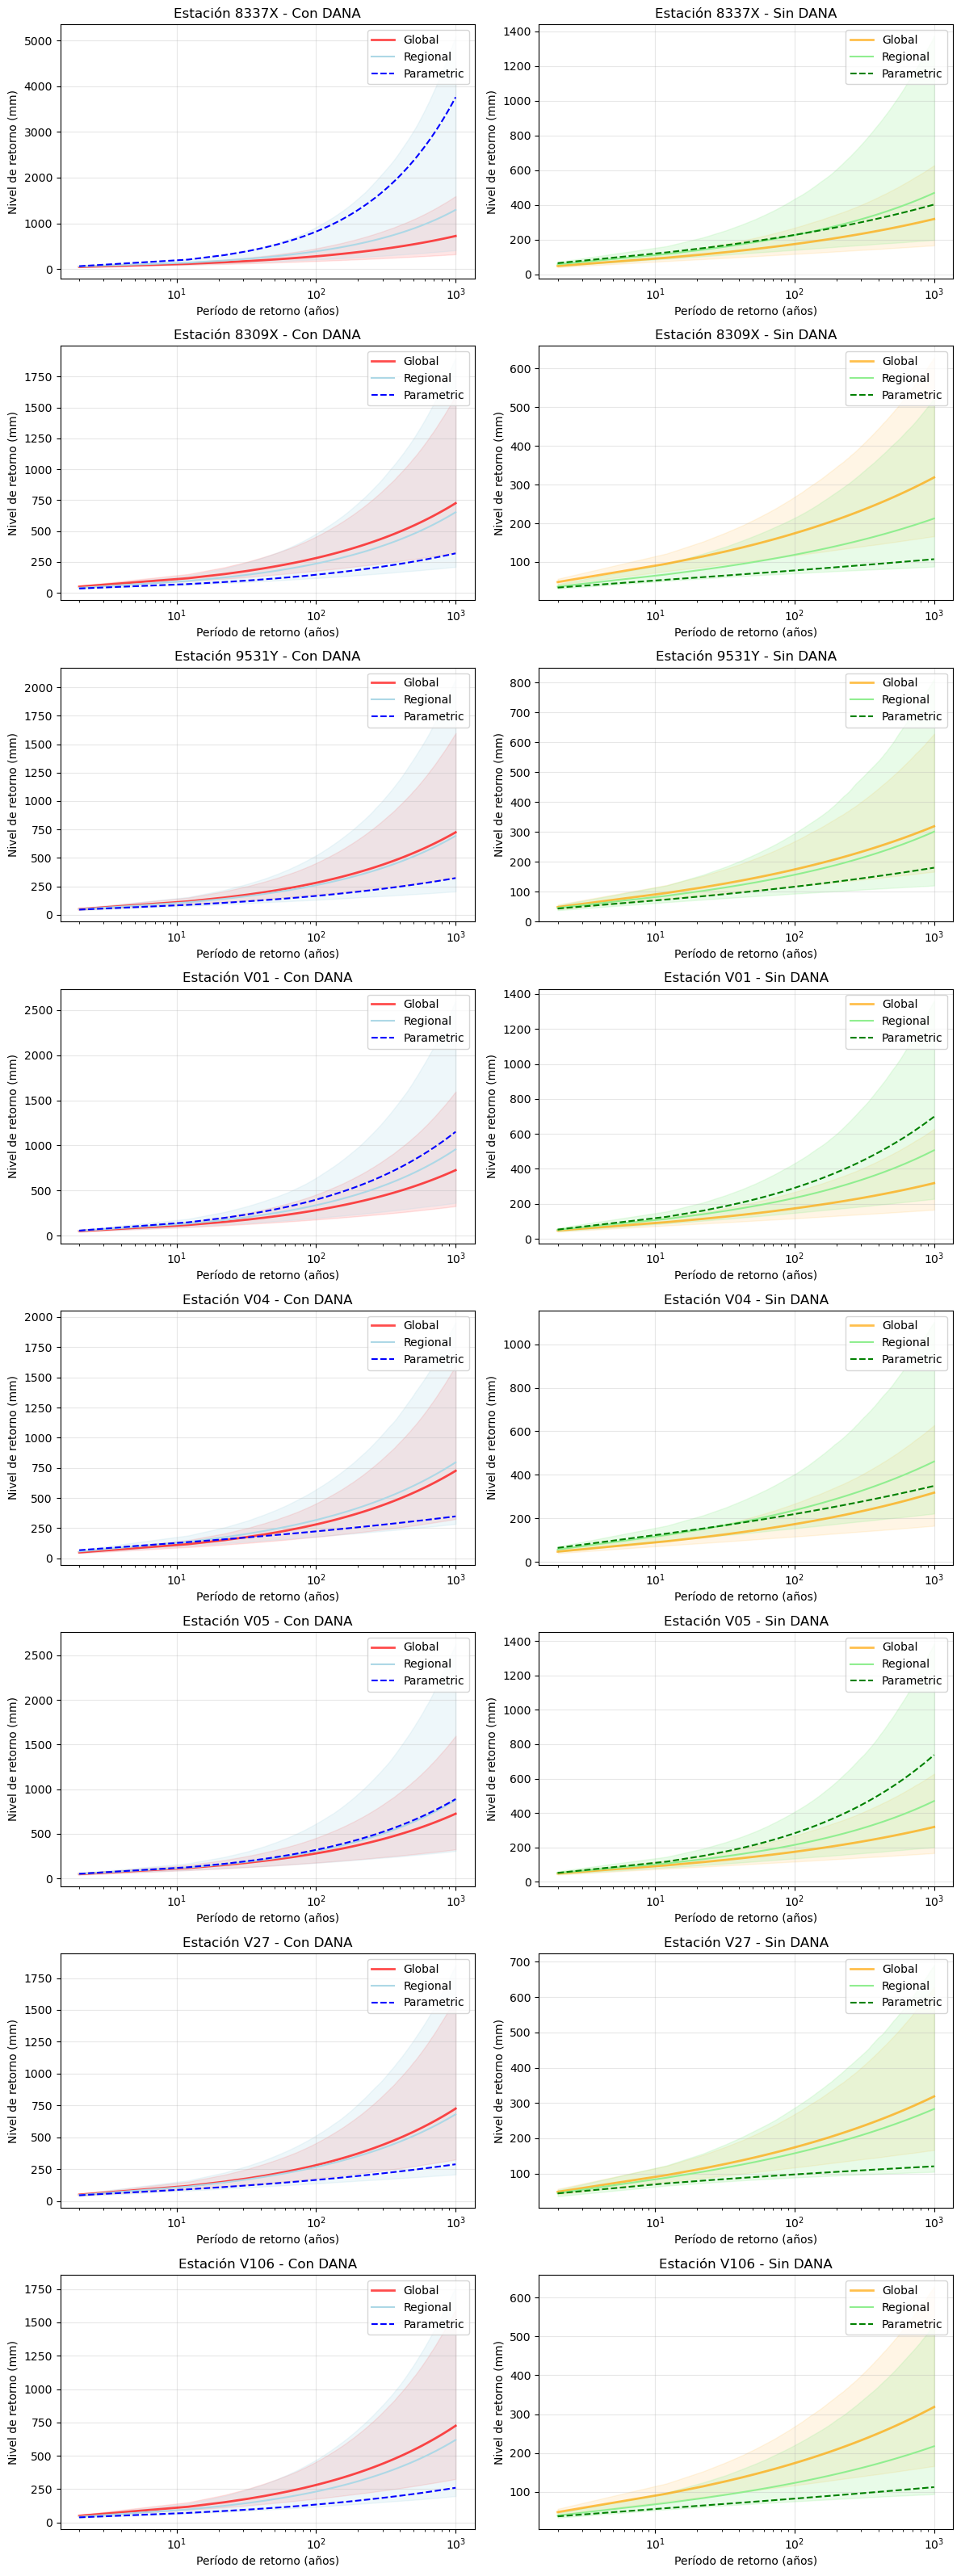

In [ ]:
def plot_return_period_station_comparison(fit_all, fit_nu, individual_fits_all, individual_fits_nu, station_names):
    """
    Genera plots lado a lado para cada estación.
    """
    # Extraer muestras
    samples_all = fit_all.extract()
    samples_nu = fit_nu.extract()
    
    n_stations = len(station_names)
    
    # Crear una figura con subplots para cada estación
    fig, axs = plt.subplots(n_stations, 2, figsize=(12, 4*n_stations))
    
    # Definir períodos de retorno
    return_periods = np.linspace(2, 1000, 100)
    probs = 1 - 1/return_periods
    
    # Colores que coinciden con el gráfico original
    colors = {
        'Regional con DANA': 'lightblue',
        'Regional sin DANA': 'lightgreen',
        'Parametric con DANA': 'blue',
        'Parametric sin DANA': 'green',
        'Global con DANA': 'red',
        'Global sin DANA': 'orange'
    }
    
    for idx, station in enumerate(station_names):
        # Plot con DANA
        ax_dana = axs[idx, 0]
        
        # Añadir curva global con DANA
        mu_global = samples_all['mu_pop']
        sigma_global = samples_all['sigma_pop']
        xi_global = samples_all['xi_pop']
        
        levels_global = np.zeros((len(mu_global), len(return_periods)))
        for i in range(len(mu_global)):
            if abs(xi_global[i]) > 1e-6:
                levels_global[i] = mu_global[i] + (sigma_global[i]/xi_global[i]) * \
                                 ((-np.log(probs))**(-xi_global[i]) - 1)
            else:
                levels_global[i] = mu_global[i] - sigma_global[i] * np.log(-np.log(probs))
        
        mean_levels_global = np.mean(levels_global, axis=0)
        ci_lower_global = np.percentile(levels_global, 2.5, axis=0)
        ci_upper_global = np.percentile(levels_global, 97.5, axis=0)
        
        ax_dana.plot(return_periods, mean_levels_global, '-', color=colors['Global con DANA'],
                    label='Global', linewidth=2, alpha=0.7)
        ax_dana.fill_between(return_periods, ci_lower_global, ci_upper_global, 
                           color=colors['Global con DANA'], alpha=0.1)
        
        # Bayesiano con DANA (station-specific)
        mu_samples = samples_all['mu_station'][:,idx]
        sigma_samples = samples_all['sigma_station'][:,idx]
        xi_samples = samples_all['xi_station'][:,idx]
        
        levels_bayes = np.zeros((len(mu_samples), len(return_periods)))
        for i in range(len(mu_samples)):
            if abs(xi_samples[i]) > 1e-6:
                levels_bayes[i] = mu_samples[i] + (sigma_samples[i]/xi_samples[i]) * \
                                 ((-np.log(probs))**(-xi_samples[i]) - 1)
            else:
                levels_bayes[i] = mu_samples[i] - sigma_samples[i] * np.log(-np.log(probs))
        
        mean_levels = np.mean(levels_bayes, axis=0)
        ci_lower = np.percentile(levels_bayes, 2.5, axis=0)
        ci_upper = np.percentile(levels_bayes, 97.5, axis=0)
        
        ax_dana.plot(return_periods, mean_levels, '-', color=colors['Regional con DANA'],
                    label='Regional')
        ax_dana.fill_between(return_periods, ci_lower, ci_upper, 
                           color=colors['Regional con DANA'], alpha=0.2)
        
        # Paramétrico con DANA
        params = individual_fits_all[station]
        if abs(params['shape']) > 1e-6:
            levels_param = params['loc'] + (params['scale']/params['shape']) * \
                          ((-np.log(probs))**(-params['shape']) - 1)
        else:
            levels_param = params['loc'] - params['scale'] * np.log(-np.log(probs))
        
        ax_dana.plot(return_periods, levels_param, '--', color=colors['Parametric con DANA'],
                    label='Parametric')
        
        # Plot sin DANA
        ax_no_dana = axs[idx, 1]
        
        # Añadir curva global sin DANA
        mu_global = samples_nu['mu_pop']
        sigma_global = samples_nu['sigma_pop']
        xi_global = samples_nu['xi_pop']
        
        levels_global = np.zeros((len(mu_global), len(return_periods)))
        for i in range(len(mu_global)):
            if abs(xi_global[i]) > 1e-6:
                levels_global[i] = mu_global[i] + (sigma_global[i]/xi_global[i]) * \
                                 ((-np.log(probs))**(-xi_global[i]) - 1)
            else:
                levels_global[i] = mu_global[i] - sigma_global[i] * np.log(-np.log(probs))
        
        mean_levels_global = np.mean(levels_global, axis=0)
        ci_lower_global = np.percentile(levels_global, 2.5, axis=0)
        ci_upper_global = np.percentile(levels_global, 97.5, axis=0)
        
        ax_no_dana.plot(return_periods, mean_levels_global, '-', color=colors['Global sin DANA'],
                       label='Global', linewidth=2, alpha=0.7)
        ax_no_dana.fill_between(return_periods, ci_lower_global, ci_upper_global, 
                              color=colors['Global sin DANA'], alpha=0.1)
        
        # Bayesiano sin DANA (station-specific)
        mu_samples = samples_nu['mu_station'][:,idx]
        sigma_samples = samples_nu['sigma_station'][:,idx]
        xi_samples = samples_nu['xi_station'][:,idx]
        
        levels_bayes = np.zeros((len(mu_samples), len(return_periods)))
        for i in range(len(mu_samples)):
            if abs(xi_samples[i]) > 1e-6:
                levels_bayes[i] = mu_samples[i] + (sigma_samples[i]/xi_samples[i]) * \
                                 ((-np.log(probs))**(-xi_samples[i]) - 1)
            else:
                levels_bayes[i] = mu_samples[i] - sigma_samples[i] * np.log(-np.log(probs))
        
        mean_levels = np.mean(levels_bayes, axis=0)
        ci_lower = np.percentile(levels_bayes, 2.5, axis=0)
        ci_upper = np.percentile(levels_bayes, 97.5, axis=0)
        
        ax_no_dana.plot(return_periods, mean_levels, '-', color=colors['Regional sin DANA'],
                       label='Regional')
        ax_no_dana.fill_between(return_periods, ci_lower, ci_upper, 
                              color=colors['Regional sin DANA'], alpha=0.2)
        
        # Paramétrico sin DANA
        params = individual_fits_nu[station]
        if abs(params['shape']) > 1e-6:
            levels_param = params['loc'] + (params['scale']/params['shape']) * \
                          ((-np.log(probs))**(-params['shape']) - 1)
        else:
            levels_param = params['loc'] - params['scale'] * np.log(-np.log(probs))
        
        ax_no_dana.plot(return_periods, levels_param, '--', color=colors['Parametric sin DANA'],
                       label='Parametric')
        
        # Configurar gráficos
        for ax, title in [(ax_dana, f'Estación {station} - Con DANA'), 
                         (ax_no_dana, f'Estación {station} - Sin DANA')]:
            ax.set_xscale('log')
            ax.set_xlabel('Período de retorno (años)')
            ax.set_ylabel('Nivel de retorno (mm)')
            ax.set_title(title)
            ax.grid(True, alpha=0.3)
            ax.legend()
    
    plt.tight_layout()
    return fig

# Ejemplo de uso
if __name__ == "__main__":
    fig = plot_return_period_station_comparison(
        fit_all, fit_nu, individual_fits_all, individual_fits_nu,
        Station_filter.columns)


ACOV error: nLogL = Inf. (0.6662768003952131, 55.13687900738429, 24.998044671063028)
ACOV error: nLogL = Inf. (0.33848359508309805, 30.328097012075375, 10.433879850934902)
ACOV error: nLogL = Inf. (0.27820137162040554, 39.67076704168048, 13.496704932795144)
ACOV error: nLogL = Inf. (0.45870968427440156, 45.958156496433745, 22.266689161268243)
ACOV error: nLogL = Inf. (0.44618890927049065, 45.52118863656407, 18.100135799683393)
ACOV error: nLogL = Inf. (0.19818825613527272, 38.2258991640911, 16.881988004571348)
ACOV error: nLogL = Inf. (0.2803845312563973, 33.68038411801153, 10.689976800610129)
ACOV error: nLogL = Inf. (0.21540152379929078, 56.114497203241015, 21.739901158961842)
ACOV error: nLogL = Inf. (0.37072368692817625, 45.005100565086416, 20.284168623006703)
ACOV error: nLogL = Inf. (0.42070452151643034, 44.55601419913425, 16.8762370681332)

Comparación de estimaciones por estación:

8337X:
Regional con DANA (media ± std):
  μ: 49.16 ± 5.06
  σ: 20.76 ± 4.35
  ξ: 0.444 ± 0.127
Re

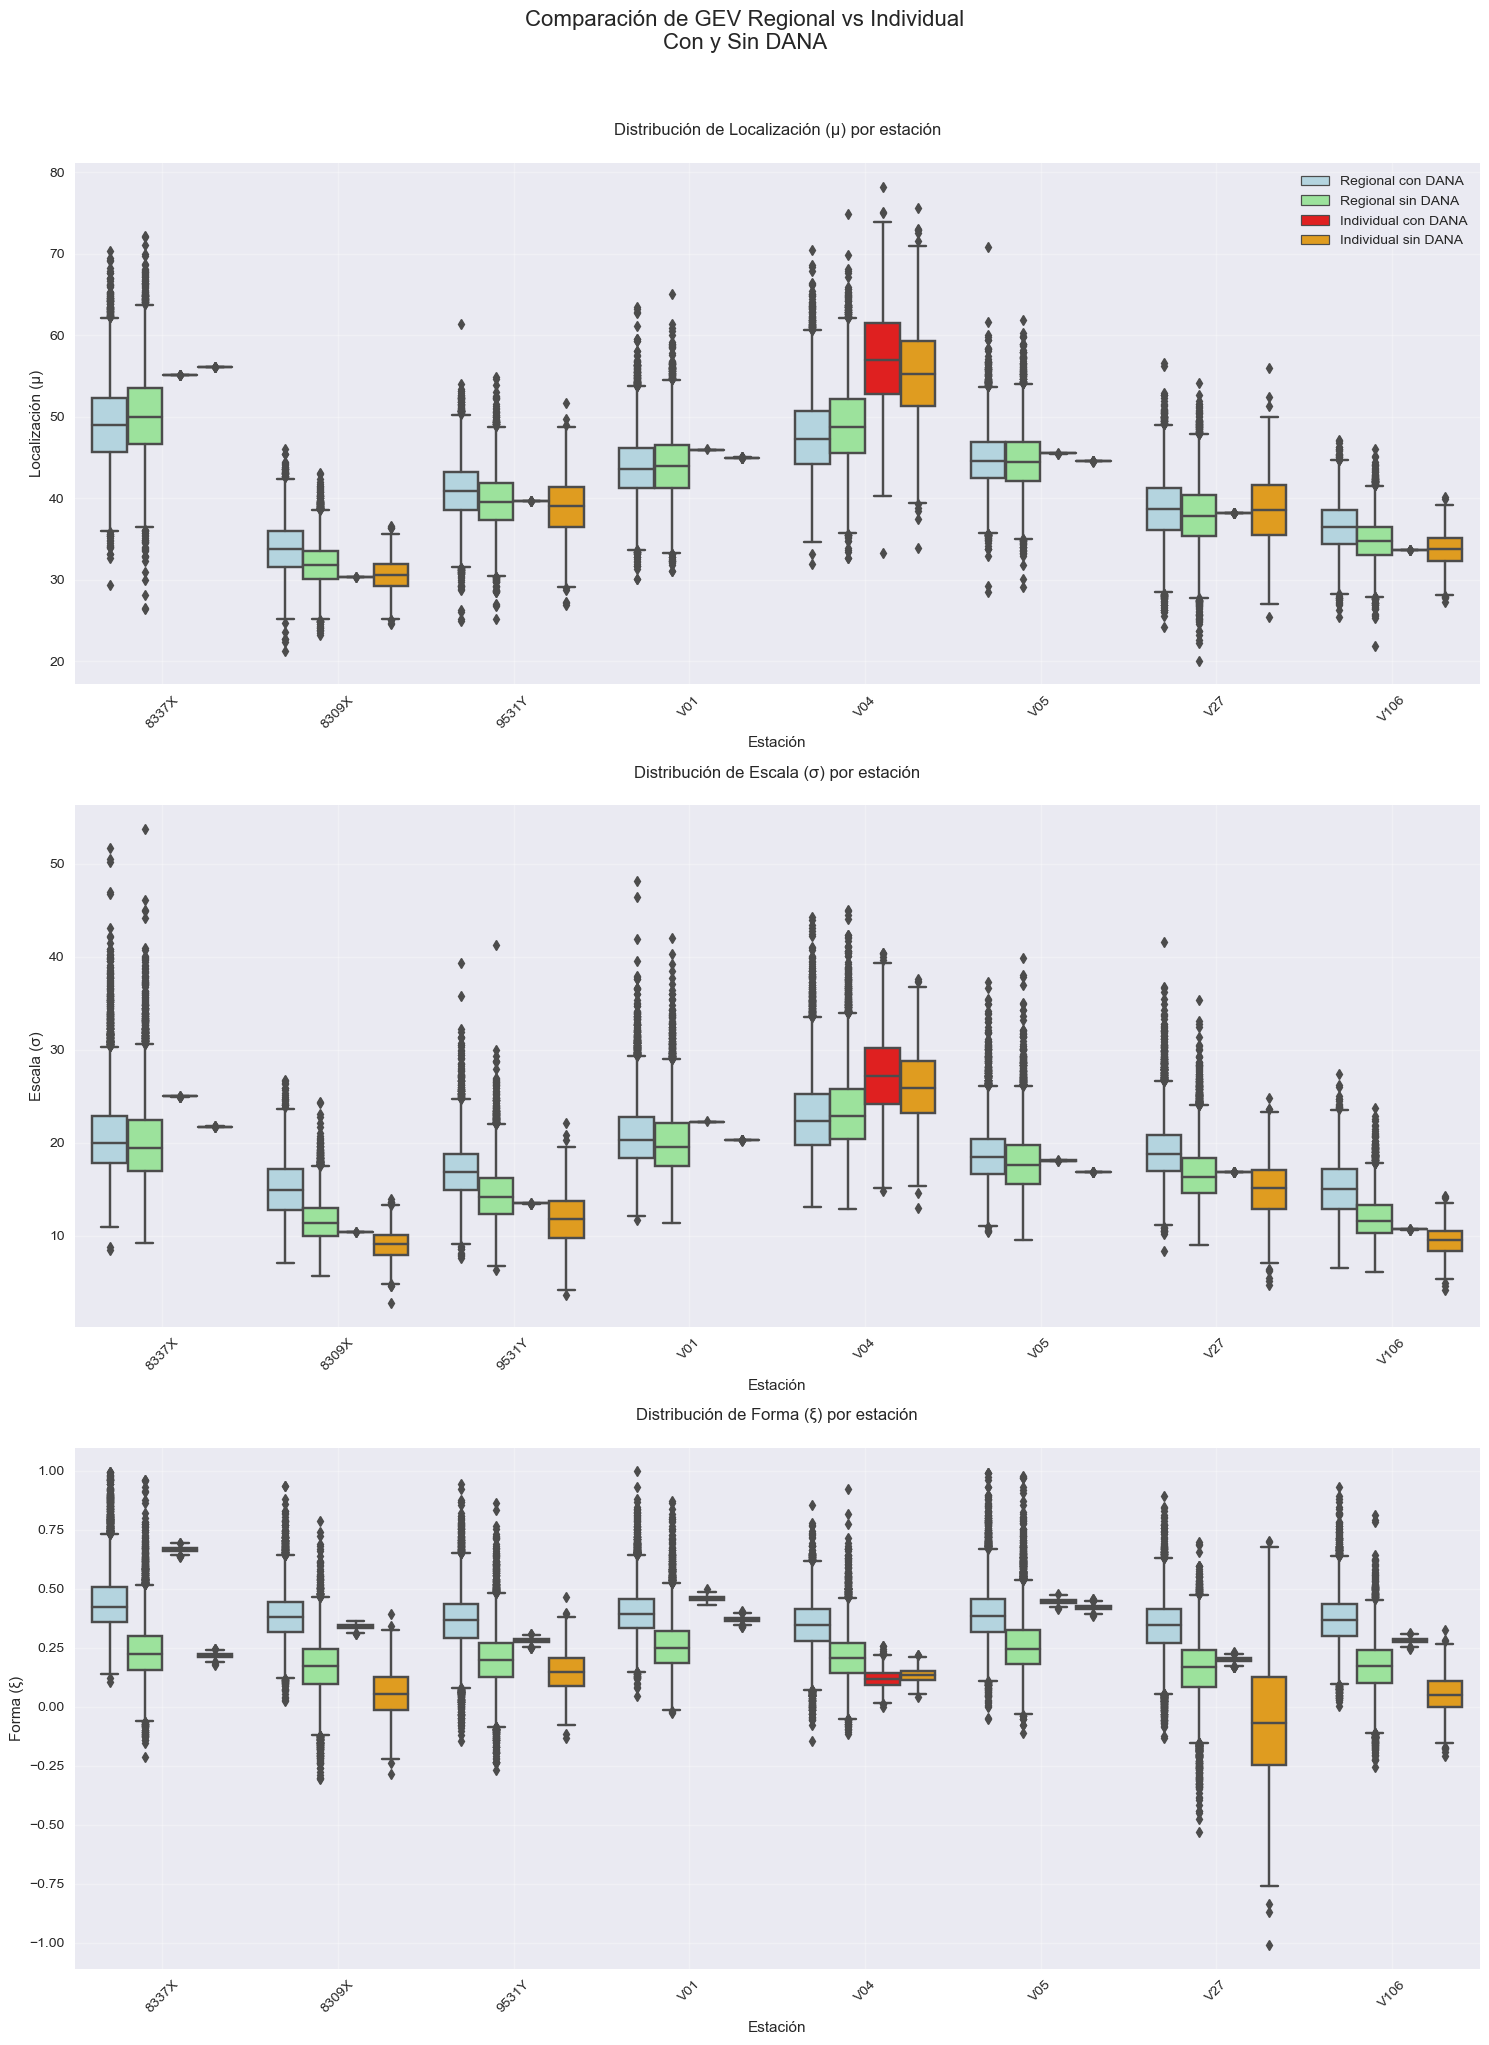

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import genextreme
from scipy.stats import multivariate_normal

def ACOV(f, theta, x):
    '''
    Calcula la matriz de varianza-covarianza asintótica usando la inversa de la matriz de información de Fisher.
    '''
    pm = 0.00001
    params = np.asarray(theta)
    dt_p = pm * params
    
    ss = len(params)
    FI = np.ones((ss,ss)) * np.nan
    
    if np.isinf(f(theta, x)):
        print('ACOV error: nLogL = Inf. {0}'.format(theta))
        return np.ones((ss,ss))*0.0001
    
    for i in range(ss):
        p1 = np.asarray(theta); p1[i] = p1[i] + dt_p[i]
        p2 = np.asarray(theta); p2[i] = p2[i] - dt_p[i]
        FI[i,i] = (f(tuple(p1), x) - 2*f(theta,x) + f(tuple(p2), x))/(dt_p[i]**2)
        
        for j in range(i+1,ss):
            p1 = np.asarray(theta); p1[i] = p1[i] - dt_p[i]
            p2 = np.asarray(theta); p2[j] = p2[j] - dt_p[j]
            p3 = np.asarray(theta); p3[i] = p3[i] - dt_p[i]; p3[j] = p3[j] - dt_p[j]
            
            cov = (f(theta,x) - f(tuple(p1),x) - f(tuple(p2),x) + f(tuple(p3),x)) \
                  / (dt_p[i]*dt_p[j])
            FI[i,j] = cov
            FI[j,i] = cov
    
    acov = np.linalg.inv(FI)
    return acov

def fit_individual_gev_fisher(data, n_sims=1000):
    """
    Ajusta GEV individual usando la matriz de información de Fisher.
    """
    results = {}
    fisher_samples = {}
    
    for col in data.columns:
        station_data = data[col].dropna()
        
        # Ajuste GEV
        params = genextreme.fit(station_data)
        theta = (-params[0], params[1], params[2])  # Cambiar signo de xi
        
        # Calcular matriz de covarianza
        acov = ACOV(genextreme.nnlf, theta, station_data)
        
        # Generar muestras usando distribución normal multivariada
        samples = multivariate_normal.rvs(mean=theta, cov=acov, size=n_sims)
        
        # Guardar resultados
        results[col] = {
            'shape': theta[0],
            'loc': theta[1],
            'scale': theta[2]
        }
        
        # Guardar muestras en DataFrame
        fisher_samples[col] = pd.DataFrame({
            'shape': samples[:,0],
            'loc': samples[:,1],
            'scale': samples[:,2]
        })
        
    return results, fisher_samples

def compare_gev_approaches(fit_all, fit_nu, station_names, data_all, data_nu, n_sims=1000):
    """
    Compara GEV regional vs individual usando matriz de Fisher.
    """
    # Ajustar GEV individual para ambos casos
    individual_fits_all, fisher_all = fit_individual_gev_fisher(data_all, n_sims)
    individual_fits_nu, fisher_nu = fit_individual_gev_fisher(data_nu, n_sims)
    
    # Preparar datos para el plot
    plot_data = []
    
    params = {
        'mu': 'Localización (μ)',
        'sigma': 'Escala (σ)',
        'xi': 'Forma (ξ)'
    }
    
    param_to_fish = {'Localización (μ)': 'loc', 
                     'Escala (σ)': 'scale', 
                     'Forma (ξ)': 'shape'}
    
    # Extraer muestras para todos los modelos
    for i, station in enumerate(station_names):
        for param_key, param_label in params.items():
            # Regional con DANA
            param_all = fit_all[f'{param_key}_station[{i+1}]']
            for value in param_all:
                plot_data.append({
                    'Estación': station,
                    'Parámetro': param_label,
                    'Valor': value,
                    'Modelo': 'Regional con DANA'
                })
            
            # Regional sin DANA
            param_nu = fit_nu[f'{param_key}_station[{i+1}]']
            for value in param_nu:
                plot_data.append({
                    'Estación': station,
                    'Parámetro': param_label,
                    'Valor': value,
                    'Modelo': 'Regional sin DANA'
                })
            
            # Fisher con DANA
            fish_param = param_to_fish[param_label]
            fish_values = fisher_all[station][fish_param]
            for value in fish_values:
                plot_data.append({
                    'Estación': station,
                    'Parámetro': param_label,
                    'Valor': value,
                    'Modelo': 'Individual con DANA'
                })
            
            # Fisher sin DANA
            fish_values = fisher_nu[station][fish_param]
            for value in fish_values:
                plot_data.append({
                    'Estación': station,
                    'Parámetro': param_label,
                    'Valor': value,
                    'Modelo': 'Individual sin DANA'
                })
    
    # Crear figura
    fig, axs = plt.subplots(3, 1, figsize=(15, 20))
    plt.subplots_adjust(hspace=0.3)
    
    # Colores para cada modelo
    colors = {'Regional con DANA': 'lightblue',
              'Regional sin DANA': 'lightgreen',
              'Individual con DANA': 'red',
              'Individual sin DANA': 'orange'}
    
    df = pd.DataFrame(plot_data)
    
    for i, (param_name, param_label) in enumerate(params.items()):
        # Subset de datos para este parámetro
        df_param = df[df['Parámetro'] == param_label]
        
        # Crear boxplot
        sns.boxplot(data=df_param, x='Estación', y='Valor', 
                   hue='Modelo', ax=axs[i],
                   palette=colors)
        
        # Personalizar plot
        axs[i].set_title(f'Distribución de {param_label} por estación', pad=20)
        axs[i].set_xlabel('Estación')
        axs[i].set_ylabel(param_label)
        axs[i].grid(True, alpha=0.3)
        
        # Rotar etiquetas
        axs[i].tick_params(axis='x', rotation=45)
        
        # Ajustar leyenda
        if i == 0:
            axs[i].legend(title='')
        else:
            axs[i].get_legend().remove()
    
    plt.suptitle('Comparación de GEV Regional vs Individual\nCon y Sin DANA', 
                y=1.02, fontsize=16)
    
    # Ajustar layout
    plt.tight_layout()
    
    # Imprimir estadísticas comparativas
    print("\nComparación de estimaciones por estación:")
    for station in station_names:
        i = list(station_names).index(station)
        print(f"\n{station}:")
        
        print("Regional con DANA (media ± std):")
        print(f"  μ: {fit_all[f'mu_station[{i+1}]'].mean():.2f} ± {fit_all[f'mu_station[{i+1}]'].std():.2f}")
        print(f"  σ: {fit_all[f'sigma_station[{i+1}]'].mean():.2f} ± {fit_all[f'sigma_station[{i+1}]'].std():.2f}")
        print(f"  ξ: {fit_all[f'xi_station[{i+1}]'].mean():.3f} ± {fit_all[f'xi_station[{i+1}]'].std():.3f}")
        
        print("Regional sin DANA (media ± std):")
        print(f"  μ: {fit_nu[f'mu_station[{i+1}]'].mean():.2f} ± {fit_nu[f'mu_station[{i+1}]'].std():.2f}")
        print(f"  σ: {fit_nu[f'sigma_station[{i+1}]'].mean():.2f} ± {fit_nu[f'sigma_station[{i+1}]'].std():.2f}")
        print(f"  ξ: {fit_nu[f'xi_station[{i+1}]'].mean():.3f} ± {fit_nu[f'xi_station[{i+1}]'].std():.3f}")
        
        print("Individual con DANA (media ± std):")
        fish_all = fisher_all[station]
        print(f"  μ: {fish_all['loc'].mean():.2f} ± {fish_all['loc'].std():.2f}")
        print(f"  σ: {fish_all['scale'].mean():.2f} ± {fish_all['scale'].std():.2f}")
        print(f"  ξ: {fish_all['shape'].mean():.3f} ± {fish_all['shape'].std():.3f}")
        
        print("Individual sin DANA (media ± std):")
        fish_nu = fisher_nu[station]
        print(f"  μ: {fish_nu['loc'].mean():.2f} ± {fish_nu['loc'].std():.2f}")
        print(f"  σ: {fish_nu['scale'].mean():.2f} ± {fish_nu['scale'].std():.2f}")
        print(f"  ξ: {fish_nu['shape'].mean():.3f} ± {fish_nu['shape'].std():.3f}")
    
    return fig, df, fisher_all, fisher_nu

# Ejemplo de uso
if __name__ == "__main__":
    fig, df_comparison, fisher_all, fisher_nu = compare_gev_approaches(
        fit_all, fit_nu, Station_filter.columns, Station_filter, Station_filter_nu)
    plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

class HierarchicalGEVModel:
    """
    Modelo GEV Jerárquico usando MLE.
    La estructura jerárquica se implementa como:
    1. μ_s = μ_pop + δ_μ_s
    2. log(σ_s) = log(σ_pop) + δ_σ_s
    3. ξ_s = ξ_pop + δ_ξ_s
    """
    def __init__(self):
        self.n_stations = None
        self.params = None
        self.hessian = None
    
    def _unpack_params(self, params):
        """Desempaqueta el vector de parámetros."""
        mu_pop = params[0]
        log_sigma_pop = params[1]
        xi_pop = params[2]
        
        # Desviaciones específicas por estación
        delta_mu = params[3:3+self.n_stations]
        delta_log_sigma = params[3+self.n_stations:3+2*self.n_stations]
        delta_xi = params[3+2*self.n_stations:]
        
        # Parámetros específicos por estación
        mu = mu_pop + delta_mu
        sigma = np.exp(log_sigma_pop + delta_log_sigma)
        xi = xi_pop + delta_xi
        
        return mu_pop, log_sigma_pop, xi_pop, mu, sigma, xi
    
    def _negative_log_likelihood(self, params, data):
        """Log-verosimilitud negativa con penalizaciones ajustadas."""
        mu_pop, log_sigma_pop, xi_pop, mu, sigma, xi = self._unpack_params(params)
        
        # Log-verosimilitud de los datos
        nll_data = 0
        for i in range(self.n_stations):
            station_data = data.iloc[:,i].dropna()
            if len(station_data) > 0:
                nll_data += -np.sum(stats.genextreme.logpdf(
                    station_data, xi[i], loc=mu[i], scale=sigma[i]))
        
        # Extraer desviaciones
        delta_mu = params[3:3+self.n_stations]
        delta_log_sigma = params[3+self.n_stations:3+2*self.n_stations]
        delta_xi = params[3+2*self.n_stations:]
        
        # Penalizaciones diferentes
        penalty_mu = 0.1 * np.sum(delta_mu**2)      # Menor penalización para mu
        penalty_sigma = 0.5 * np.sum(delta_log_sigma**2)
        penalty_xi = 1.0 * np.sum(delta_xi**2)
        
        return nll_data + penalty_mu + penalty_sigma + penalty_xi

    def fit(self, data):
        """Ajuste más eficiente del modelo."""
        self.n_stations = data.shape[1]
        
        # Valores iniciales informados
        init_mu_pop = np.nanmedian(data.values)
        init_sigma_pop = np.nanstd(data.values)
        init_xi_pop = 0.1
        
        # Desviaciones iniciales pequeñas
        init_delta_mu = np.zeros(self.n_stations)
        init_delta_sigma = np.zeros(self.n_stations)
        init_delta_xi = np.zeros(self.n_stations)
        
        # Vector inicial
        init_params = np.concatenate([
            [init_mu_pop, np.log(init_sigma_pop), init_xi_pop],
            init_delta_mu, init_delta_sigma, init_delta_xi
        ])
        
        # Una sola optimización con buen método
        result = minimize(
            self._negative_log_likelihood,
            init_params,
            args=(data,),
            method='BFGS',  # Método más eficiente
            options={'maxiter': 1000}  # Menos iteraciones
        )
        
        self.params = result.x
        
        # Calcular matriz Hessiana
        eps = 1e-5
        n_params = len(self.params)
        H = np.zeros((n_params, n_params))
        
        for i in range(n_params):
            for j in range(i, n_params):
                params_pp = self.params.copy()
                params_pm = self.params.copy()
                params_mp = self.params.copy()
                params_mm = self.params.copy()
                
                params_pp[i] += eps; params_pp[j] += eps
                params_pm[i] += eps; params_pm[j] -= eps
                params_mp[i] -= eps; params_mp[j] += eps
                params_mm[i] -= eps; params_mm[j] -= eps
                
                H[i,j] = H[j,i] = (
                    self._negative_log_likelihood(params_pp, data) -
                    self._negative_log_likelihood(params_pm, data) -
                    self._negative_log_likelihood(params_mp, data) +
                    self._negative_log_likelihood(params_mm, data)
                ) / (4 * eps * eps)
        
        self.hessian = H
        return result

    def get_params(self):
        """Retorna los parámetros estimados y sus errores estándar."""
        if self.params is None:
            raise ValueError("El modelo debe ser ajustado primero")
            
        mu_pop, log_sigma_pop, xi_pop, mu, sigma, xi = self._unpack_params(self.params)
        se = np.sqrt(np.diag(np.linalg.inv(self.hessian)))
        
        return {
            'population': {
                'mu': (mu_pop, se[0]),
                'sigma': (np.exp(log_sigma_pop), np.exp(log_sigma_pop) * se[1]),
                'xi': (xi_pop, se[2])
            },
            'station': {
                'mu': list(zip(mu, se[3:3+self.n_stations])),
                'sigma': list(zip(sigma, sigma * se[3+self.n_stations:3+2*self.n_stations])),
                'xi': list(zip(xi, se[3+2*self.n_stations:]))
            }
        }

    def return_levels(self, periods):
        """Calcula niveles de retorno."""
        mu_pop, log_sigma_pop, xi_pop, mu, sigma, xi = self._unpack_params(self.params)
        
        return_levels = np.zeros((self.n_stations, len(periods)))
        for i in range(self.n_stations):
            for j, T in enumerate(periods):
                p = 1 - 1/T
                if xi[i] != 0:
                    return_levels[i,j] = mu[i] + (sigma[i]/xi[i]) * \
                                       ((-np.log(p))**(-xi[i]) - 1)
                else:
                    return_levels[i,j] = mu[i] - sigma[i] * np.log(-np.log(p))
        
        return return_levels

def extract_station_parameters(model, station_names):
    """
    Extrae y organiza los parámetros GEV para todas las estaciones.
    """
    params = model.get_params()
    
    # Extraer parámetros y errores estándar
    results = []
    params_only = []
    
    for i, station in enumerate(station_names):
        # Extraer parámetros y errores estándar
        mu, mu_se = params['station']['mu'][i]
        sigma, sigma_se = params['station']['sigma'][i]
        xi, xi_se = params['station']['xi'][i]
        
        # Cambiar el signo del parámetro de forma
        xi = -xi  # Convertir a la parametrización de Stan
        
        results.append({
            'Station': station,
            'location': mu,
            'location_se': mu_se,
            'scale': sigma,
            'scale_se': sigma_se,
            'shape': xi,
            'shape_se': xi_se
        })
        
        params_only.append({
            'Station': station,
            'location': mu,
            'scale': sigma,
            'shape': xi
        })
    
    # Crear DataFrames
    df_results = pd.DataFrame(results)
    df_params = pd.DataFrame(params_only)
    
    # Añadir parámetros poblacionales
    pop_params = {
        'Station': 'Population',
        'location': params['population']['mu'][0],
        'location_se': params['population']['mu'][1],
        'scale': params['population']['sigma'][0],
        'scale_se': params['population']['sigma'][1],
        'shape': -params['population']['xi'][0],
        'shape_se': params['population']['xi'][1]
    }
    
    df_results = pd.concat([df_results, pd.DataFrame([pop_params])], ignore_index=True)
    
    return df_results, df_params

def plot_station_parameters(df_results):
    """Visualiza los parámetros GEV y sus intervalos de confianza."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    params = ['location', 'scale', 'shape']
    titles = ['Ubicación (μ)', 'Escala (σ)', 'Forma (ξ)']
    
    for ax, param, title in zip(axes, params, titles):
        # Excluir la población para el gráfico
        df_plot = df_results[df_results['Station'] != 'Population'].copy()
        
        # Ordenar por valor del parámetro
        df_plot = df_plot.sort_values(param)
        
        # Plotear parámetros con intervalos de confianza
        ax.errorbar(
            df_plot[param],
            range(len(df_plot)),
            xerr=1.96 * df_plot[f'{param}_se'],
            fmt='o',
            capsize=5
        )
        
        # Añadir línea vertical para el valor poblacional
        pop_value = df_results[df_results['Station'] == 'Population'][param].values[0]
        pop_se = df_results[df_results['Station'] == 'Population'][f'{param}_se'].values[0]
        ax.axvspan(pop_value - 1.96*pop_se, pop_value + 1.96*pop_se, 
                  alpha=0.2, color='red', label='IC 95% poblacional')
        ax.axvline(pop_value, color='red', linestyle='--', label='Media poblacional')
        
        ax.set_title(title)
        ax.set_yticks(range(len(df_plot)))
        ax.set_yticklabels(df_plot['Station'])
        ax.grid(True, alpha=0.3)
        ax.legend()
    
    plt.tight_layout()
    return fig


c:\Users\urread\.conda\envs\stan_env\lib\site-packages\scipy\optimize\_numdiff.py:557: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
c:\Users\urread\.conda\envs\stan_env\lib\site-packages\scipy\optimize\_numdiff.py:557: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
c:\Users\urread\.conda\envs\stan_env\lib\site-packages\scipy\optimize\_numdiff.py:557: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


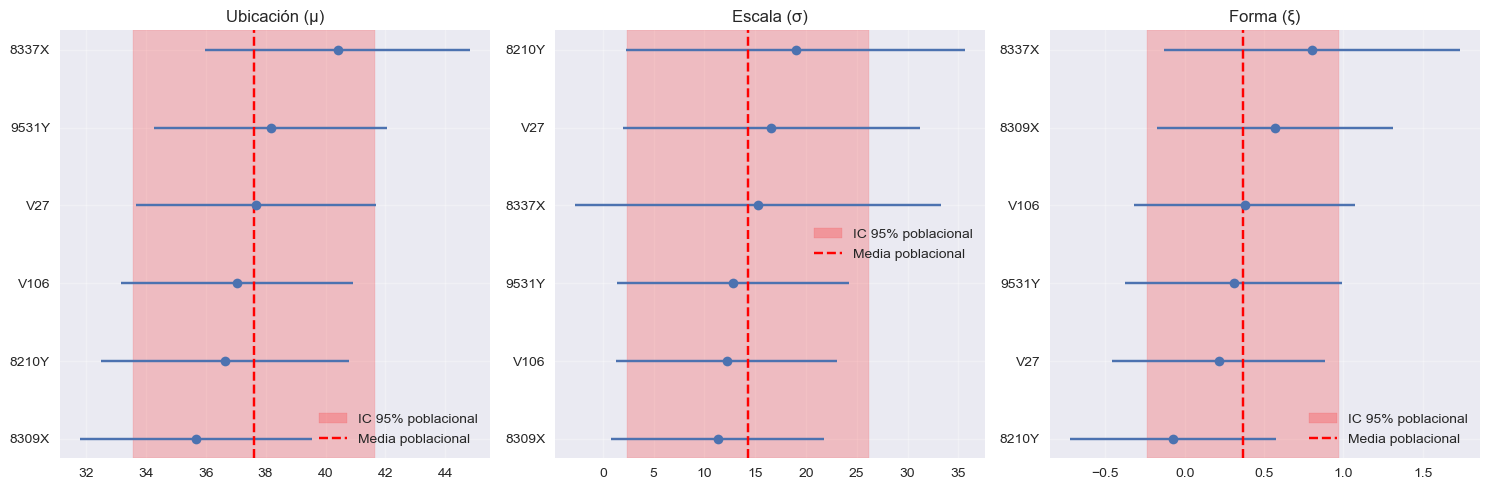


Parámetros por estación:
  Station   location      scale     shape
0   8337X  40.414803  15.269601  0.802855
1   8210Y  36.641803  18.976739 -0.076241
2   8309X  35.677480  11.311074  0.568296
3   9531Y  38.168429  12.833639  0.308416
4    V106  37.044248  12.195709  0.377394
5     V27  37.694964  16.597295  0.214353


In [ ]:
model = HierarchicalGEVModel()
fit = model.fit(Station_filter)

# Extraer y visualizar resultados
df_results, df_params = extract_station_parameters(model, Station_filter.columns)
fig = plot_station_parameters(df_results)
plt.show()

# Ver resultados
print("\nParámetros por estación:")
print(df_params)



Comparación de parámetros (Paramétrico vs Bayesiano):

8337X:
  μ: 40.41 vs 45.87
  σ: 15.27 vs 19.34
  ξ: 0.803 vs 0.560

8210Y:
  μ: 36.64 vs 32.90
  σ: 18.98 vs 19.64
  ξ: -0.076 vs 0.118

8309X:
  μ: 35.68 vs 36.16
  σ: 11.31 vs 13.96
  ξ: 0.568 vs 0.511

9531Y:
  μ: 38.17 vs 39.55
  σ: 12.83 vs 15.96
  ξ: 0.308 vs 0.339

V106:
  μ: 37.04 vs 37.60
  σ: 12.20 vs 14.99
  ξ: 0.377 vs 0.405

V27:
  μ: 37.69 vs 37.57
  σ: 16.60 vs 18.02
  ξ: 0.214 vs 0.290


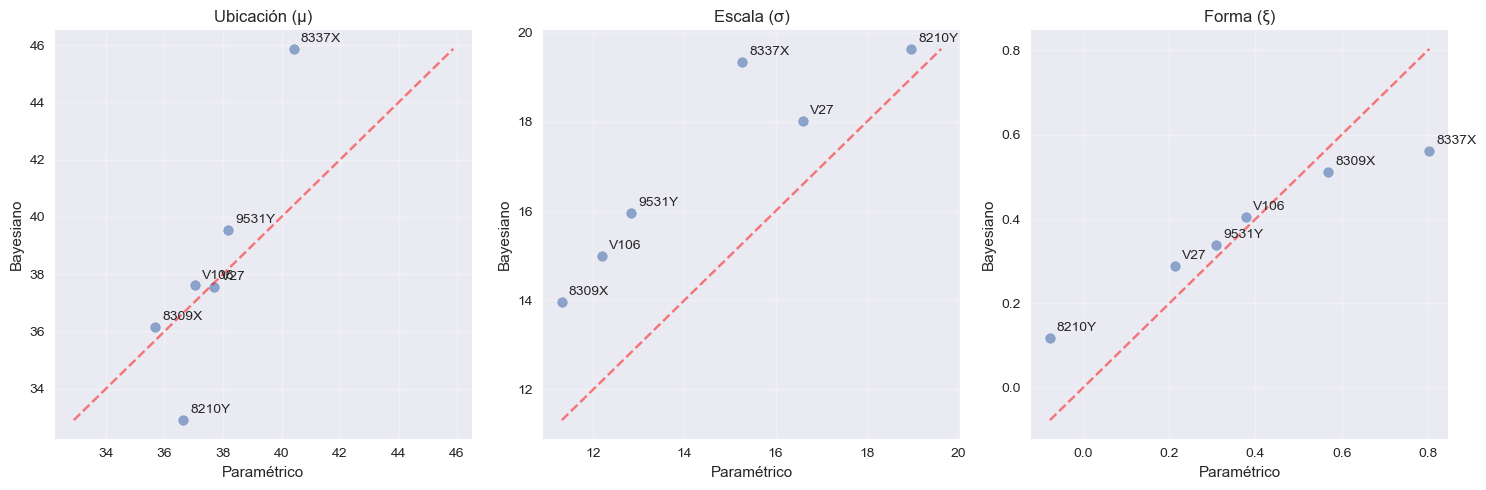

In [ ]:
def extract_station_parameters(model, station_names):
    """
    Extrae y organiza los parámetros GEV para todas las estaciones.
    Convierte el parámetro de forma para que coincida con la parametrización de Stan.
    """
    params = model.get_params()
    
    # Extraer parámetros y errores estándar
    results = []
    params_only = []
    
    for i, station in enumerate(station_names):
        # Extraer parámetros y errores estándar
        mu, mu_se = params['station']['mu'][i]
        sigma, sigma_se = params['station']['sigma'][i]
        xi, xi_se = params['station']['xi'][i]
        
        # Cambiar el signo del parámetro de forma y su error estándar
        xi = -xi  # Convertir a la parametrización de Stan
        
        results.append({
            'Station': station,
            'location': mu,
            'location_se': mu_se,
            'scale': sigma,
            'scale_se': sigma_se,
            'shape': xi,  # Ya convertido
            'shape_se': xi_se
        })
        
        params_only.append({
            'Station': station,
            'location': mu,
            'scale': sigma,
            'shape': xi  # Ya convertido
        })
    
    # Crear DataFrames
    df_results = pd.DataFrame(results)
    df_params = pd.DataFrame(params_only)
    
    # Añadir parámetros poblacionales (también convertidos)
    pop_params = {
        'Station': 'Population',
        'location': params['population']['mu'][0],
        'location_se': params['population']['mu'][1],
        'scale': params['population']['sigma'][0],
        'scale_se': params['population']['sigma'][1],
        'shape': -params['population']['xi'][0],  # Cambiar signo
        'shape_se': params['population']['xi'][1]
    }
    
    df_results = pd.concat([df_results, pd.DataFrame([pop_params])], ignore_index=True)
    
    return df_results, df_params

# Función para comparar resultados bayesianos y frecuentistas
def compare_parameters(params_freq, samples_bayes, station_names):
    """
    Compara los parámetros del modelo frecuentista con el bayesiano.
    
    Args:
        params_freq: DataFrame con los parámetros del modelo frecuentista
        samples_bayes: Diccionario con las muestras del modelo bayesiano
        station_names: Nombres de las estaciones
    """
    comparison = []
    
    for i, station in enumerate(station_names):
        # Parámetros frecuentistas
        freq_params = params_freq[params_freq['Station'] == station].iloc[0]
        
        # Parámetros bayesianos
        bayes_mu = np.mean(samples_bayes['mu_station'][:,i])
        bayes_sigma = np.mean(samples_bayes['sigma_station'][:,i])
        bayes_xi = np.mean(samples_bayes['xi_station'][:,i])
        
        comparison.append({
            'Station': station,
            'mu_freq': freq_params['location'],
            'mu_bayes': bayes_mu,
            'sigma_freq': freq_params['scale'],
            'sigma_bayes': bayes_sigma,
            'xi_freq': freq_params['shape'],  # Ya convertido
            'xi_bayes': bayes_xi
        })
    
    df_comparison = pd.DataFrame(comparison)
    
    # Visualizar comparación
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    params = [('mu', 'Ubicación (μ)'), 
              ('sigma', 'Escala (σ)'), 
              ('xi', 'Forma (ξ)')]
    
    for (param, title), ax in zip(params, axes):
        ax.scatter(df_comparison[f'{param}_freq'], 
                  df_comparison[f'{param}_bayes'],
                  alpha=0.6)
        
        # Línea de identidad
        min_val = min(df_comparison[f'{param}_freq'].min(), 
                     df_comparison[f'{param}_bayes'].min())
        max_val = max(df_comparison[f'{param}_freq'].max(), 
                     df_comparison[f'{param}_bayes'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
        
        ax.set_xlabel('Paramétrico')
        ax.set_ylabel('Bayesiano')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        
        # Añadir etiquetas de estaciones
        for idx, row in df_comparison.iterrows():
            ax.annotate(row['Station'], 
                       (row[f'{param}_freq'], row[f'{param}_bayes']),
                       xytext=(5, 5), textcoords='offset points')
    
    plt.tight_layout()
    
    # Imprimir diferencias
    print("\nComparación de parámetros (Paramétrico vs Bayesiano):")
    for _, row in df_comparison.iterrows():
        print(f"\n{row['Station']}:")
        print(f"  μ: {row['mu_freq']:.2f} vs {row['mu_bayes']:.2f}")
        print(f"  σ: {row['sigma_freq']:.2f} vs {row['sigma_bayes']:.2f}")
        print(f"  ξ: {row['xi_freq']:.3f} vs {row['xi_bayes']:.3f}")
    
    return df_comparison, fig

# Ejemplo de uso
if __name__ == "__main__":
    # Obtener parámetros del modelo frecuentista
    df_results, df_params = extract_station_parameters(model, Station_filter.columns)
    
    # Comparar con resultados bayesianos
    df_comparison, fig = compare_parameters(df_params, samples, Station_filter.columns)
    plt.show()
